<div class="alert alert-block alert-info">
    <h2 align="center"style="color: black;">Machine Learning-based Algorithmic Trading</h2>
    <h3 align="center"style="color: black;">Data & Walk Forward Backtest Pipelines</h3>
    <h5 align="center"style="color: black;"><em>Alpha Hunters</em></h5>
</div>

# Kaggle services and tools

In [1]:
!pip install feature_engine
!pip install colorlog
!pip install betacal
!pip install venn_abers
!pip install cudf
!pip install arch
!pip install scikit-learn==1.5.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.0/375.0 kB 10.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 88.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 91.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.1.4
    Uninstalling pandas-2.1.4:
      Successfully uninstalled pandas-2.1.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pandas<2.2.2dev0,>=2.0, but you have pandas 2.2.3 which is incompatible.
cudf-cu12 24.4.1 requires pyarrow<15.0.0a0,>=14.0.1, 

In [2]:
!pip show xgboost

Name: xgboost
Version: 2.0.3
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /usr/local/lib/python3.10/dist-packages
Requires: numpy, scipy
Required-by: TPOT


In [3]:
model_type = 'CF-XGBF' # ['XGB', 'CF-XGB', 'XGBF', 'CF-XGBF', 'RF', 'CF-RF', 'LGBM', 'CF-LGBM']
symbols = [
    "XAUUSD",
    # "US30",
    # "US100",
    # "EURUSD",
    # "GBPUSD",
    # "USDJPY",
    # "BTCUSD"
]
target_symbol = "XAUUSD"
MANUAL_EXP = True

In [4]:
print(MANUAL_EXP)

True


# Weights & Biase

![ChessUrl](https://docs.wandb.ai/assets/images/wandb_demo_experiments-4797af7fe7236d6c5c42adbdc93deb4c.gif "chess")

Steps:
- Create a W&B account [wandb.ai](https://wandb.ai/)
- Read docs [W&B docs](https://docs.wandb.ai/)
- Install using pip:  `!pip install wandb`
- Get API token [link](https://wandb.ai/authorize)
- Create a secret or an env variable for the token

In [5]:
import wandb
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value = user_secrets.get_secret("wandb_token")
wandb.login(key=secret_value) 

api = wandb.Api()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: amirhosseinfarahani (alpha-hunters). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [6]:
!wandb login

wandb: Currently logged in as: amirhosseinfarahani (alpha-hunters). Use `wandb login --relogin` to force relogin


# Read functions from the GitHub repo

- GitHub account and repo
- Generate an access token on your GitHub account [Link](https://github.com/settings/tokens)
- Then make a secret or an environment variable to use it

In [7]:
import sys
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
token = user_secrets.get_secret("GITHUB_TOKEN")
branch_name = 'main' # ['main', 'm.mahdi', 'masoud']
!rm -r ./ML-Algotrading-Project &> /dev/null
!git clone -b {branch_name} https://{token}@github.com/AmirhsFar/ML-Algotrading-Project.git &> /dev/null
!pip install -r ./ML-Algotrading-Project/dataset/requirements.txt
sys.path.append("/kaggle/working/ML-Algotrading-Project")
print('All done')
# !tail -n 120 ./forex_MLOps/main_func.py  
# !tail -n 120 ./forex_MLOps/select_columns.py  

ERROR: Could not find a version that satisfies the requirement MetaTrader5==5.0.4424 (from versions: none)
ERROR: No matching distribution found for MetaTrader5==5.0.4424
All done


In [8]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from dataset.configs.feature_configs_general import generate_general_config
from dataset.dukascopy_func import (
    crawl_OHLCV_data_dukascopy
)
from dataset.history_data_stage_one_func import (
    history_data_stage_one
)
from dataset.realtime_candle_func import (
    historiy_realtime_candle
)
from dataset.indicator_func import history_indicator_calculator
from dataset.realtime_shift_func import history_cndl_shift
from dataset.create_basic_features_func import (
    history_basic_features,
    history_fe_market_close,
    history_fe_time
)
from dataset.window_agg_features_func import (
    history_fe_WIN_features
)
from dataset.columns_merge_func import history_columns_merge
# from dataset.data_crawlers.metatrader_func import (
#     crawl_OHLCV_data_metatrader,
# )
from main_func import main
# from forex_MLOps.utils.wandb_utils import read_obj
from ETL import read_data_manual, ETL
# from forex_MLOps.model_ensemble import QuantEnsemble
from utils.wandb_utils import fetch_artifacts, read_tracker_objects, download_wandb_artifact
########### READ DATA MANUALLY #########
# df_all = read_data_manual()
# !tail -n 120 ./forex_MLOps/ETL.py  

# 0. Data Fetching & Preprocessing

## Features' Config

In [9]:
config_general = generate_general_config(symbols)

## Dukascopy

In [10]:
# failed_dates_dict = await crawl_OHLCV_data_dukascopy(
#     feature_config = config_general 
# )

In [11]:
# import pandas as pd

# pd.set_option('display.max_columns', None)
# df = pd.read_parquet(
#     f"/kaggle/working/ML-Algotrading-Project/dataset/data/raw_data/dukascopy/EURUSD_dukascopy.parquet"
# )
# df.iloc[[1000, 1006, 11012]]

## Metatrader 5

Do this section in your system and place the `.parquet` file in *dataset\data\raw_data\metatrader*, then reclone the repository and proceed for the furthur steps.

## Creating Stage-One Data

In [12]:
# history_data_stage_one(config_general)

In [13]:
import pandas as pd

df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/stage_one_data/{target_symbol}_stage_one.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 120000]]

,_time,_date,open,high,low,close,tick_volume,spread,was_ffilled
1,2017-04-10 00:05:00,2017-04-10,1254.92,1254.92,1254.25,1254.72,165.0,0.0,False
5,2017-04-10 00:25:00,2017-04-10,1254.42,1254.50,1254.23,1254.35,76.0,0.0,False
1000,2017-04-13 14:20:00,2017-04-13,1286.63,1287.25,1286.56,1287.03,539.0,0.0,False
2006,2017-04-20 06:10:00,2017-04-20,1279.18,1279.19,1278.44,1278.44,220.0,26.0,False
11012,2017-06-05 20:40:00,2017-06-05,1279.14,1279.22,1279.02,1279.10,236.0,5.0,False
120000,2018-12-13 18:00:00,2018-12-13,1242.99,1243.40,1242.99,1243.26,718.0,2.0,False


In [14]:
if len(symbols) >= 2:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/stage_one_data/{symbols[1]}_stage_one.parquet"
    )

df.iloc[[1, 5, 1000, 2006, 11012, 120000]]

,_time,_date,open,high,low,close,tick_volume,spread,was_ffilled
1,2017-04-10 00:05:00,2017-04-10,1254.92,1254.92,1254.25,1254.72,165.0,0.0,False
5,2017-04-10 00:25:00,2017-04-10,1254.42,1254.50,1254.23,1254.35,76.0,0.0,False
1000,2017-04-13 14:20:00,2017-04-13,1286.63,1287.25,1286.56,1287.03,539.0,0.0,False
2006,2017-04-20 06:10:00,2017-04-20,1279.18,1279.19,1278.44,1278.44,220.0,26.0,False
11012,2017-06-05 20:40:00,2017-06-05,1279.14,1279.22,1279.02,1279.10,236.0,5.0,False
120000,2018-12-13 18:00:00,2018-12-13,1242.99,1243.40,1242.99,1243.26,718.0,2.0,False


In [15]:
if len(symbols) >= 3:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/stage_one_data/{symbols[2]}_stage_one.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 120000]]

,_time,_date,open,high,low,close,tick_volume,spread,was_ffilled
1,2017-04-10 00:05:00,2017-04-10,1254.92,1254.92,1254.25,1254.72,165.0,0.0,False
5,2017-04-10 00:25:00,2017-04-10,1254.42,1254.50,1254.23,1254.35,76.0,0.0,False
1000,2017-04-13 14:20:00,2017-04-13,1286.63,1287.25,1286.56,1287.03,539.0,0.0,False
2006,2017-04-20 06:10:00,2017-04-20,1279.18,1279.19,1278.44,1278.44,220.0,26.0,False
11012,2017-06-05 20:40:00,2017-06-05,1279.14,1279.22,1279.02,1279.10,236.0,5.0,False
120000,2018-12-13 18:00:00,2018-12-13,1242.99,1243.40,1242.99,1243.26,718.0,2.0,False


## Creating Real-Time Candles

In [16]:
historiy_realtime_candle(config_general)

  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> start historiy_realtime_candle fumc:
  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:symbol: XAUUSD
  [test run][INFO]:--> XAUUSD saved.
  [test run][INFO]:--> historiy_realtime_candle run successfully.


In [17]:
df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/realtime_candle/{target_symbol}_realtime_candle.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,index,M5_OPEN,M5_CLOSE,M5_LOW,M5_HIGH,M5_VOLUME,_date,minutesPassed,isFirst,...,M720_HIGH,M720_LOW,M720_CLOSE,M720_VOLUME,M1440_OPEN,M1440_HIGH,M1440_LOW,M1440_CLOSE,M1440_VOLUME,symbol
1,2017-04-10 00:05:00,1,1254.92,1254.72,1254.25,1254.92,165.0,2017-04-10,5,0,...,1255.08,1253.87,1254.72,463.0,1254.29,1255.08,1253.87,1254.72,463.0,XAUUSD
5,2017-04-10 00:25:00,5,1254.42,1254.35,1254.23,1254.50,76.0,2017-04-10,25,0,...,1255.24,1253.87,1254.35,839.0,1254.29,1255.24,1253.87,1254.35,839.0,XAUUSD
1000,2017-04-13 14:20:00,1000,1286.63,1287.03,1286.56,1287.25,539.0,2017-04-13,860,0,...,1288.62,1285.68,1287.03,10303.0,1285.94,1288.62,1283.89,1287.03,58922.0,XAUUSD
2006,2017-04-20 06:10:00,2006,1279.18,1278.44,1278.44,1279.19,220.0,2017-04-20,370,0,...,1281.03,1278.07,1278.44,13771.0,1278.44,1281.03,1278.07,1278.44,13771.0,XAUUSD
11012,2017-06-05 20:40:00,11012,1279.14,1279.10,1279.02,1279.22,236.0,2017-06-05,1240,0,...,1283.46,1277.79,1279.10,67773.0,1279.79,1283.46,1277.79,1279.10,121404.0,XAUUSD
20000,2017-07-20 10:40:00,20000,1237.97,1237.87,1237.85,1238.18,578.0,2017-07-20,640,0,...,1242.55,1236.62,1237.87,56317.0,1240.92,1242.55,1236.62,1237.87,56317.0,XAUUSD


In [18]:
if len(symbols) >= 2:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/realtime_candle/{symbols[1]}_realtime_candle.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,index,M5_OPEN,M5_CLOSE,M5_LOW,M5_HIGH,M5_VOLUME,_date,minutesPassed,isFirst,...,M720_HIGH,M720_LOW,M720_CLOSE,M720_VOLUME,M1440_OPEN,M1440_HIGH,M1440_LOW,M1440_CLOSE,M1440_VOLUME,symbol
1,2017-04-10 00:05:00,1,1254.92,1254.72,1254.25,1254.92,165.0,2017-04-10,5,0,...,1255.08,1253.87,1254.72,463.0,1254.29,1255.08,1253.87,1254.72,463.0,XAUUSD
5,2017-04-10 00:25:00,5,1254.42,1254.35,1254.23,1254.50,76.0,2017-04-10,25,0,...,1255.24,1253.87,1254.35,839.0,1254.29,1255.24,1253.87,1254.35,839.0,XAUUSD
1000,2017-04-13 14:20:00,1000,1286.63,1287.03,1286.56,1287.25,539.0,2017-04-13,860,0,...,1288.62,1285.68,1287.03,10303.0,1285.94,1288.62,1283.89,1287.03,58922.0,XAUUSD
2006,2017-04-20 06:10:00,2006,1279.18,1278.44,1278.44,1279.19,220.0,2017-04-20,370,0,...,1281.03,1278.07,1278.44,13771.0,1278.44,1281.03,1278.07,1278.44,13771.0,XAUUSD
11012,2017-06-05 20:40:00,11012,1279.14,1279.10,1279.02,1279.22,236.0,2017-06-05,1240,0,...,1283.46,1277.79,1279.10,67773.0,1279.79,1283.46,1277.79,1279.10,121404.0,XAUUSD
20000,2017-07-20 10:40:00,20000,1237.97,1237.87,1237.85,1238.18,578.0,2017-07-20,640,0,...,1242.55,1236.62,1237.87,56317.0,1240.92,1242.55,1236.62,1237.87,56317.0,XAUUSD


In [19]:
if len(symbols) >= 3:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/realtime_candle/{symbols[2]}_realtime_candle.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,index,M5_OPEN,M5_CLOSE,M5_LOW,M5_HIGH,M5_VOLUME,_date,minutesPassed,isFirst,...,M720_HIGH,M720_LOW,M720_CLOSE,M720_VOLUME,M1440_OPEN,M1440_HIGH,M1440_LOW,M1440_CLOSE,M1440_VOLUME,symbol
1,2017-04-10 00:05:00,1,1254.92,1254.72,1254.25,1254.92,165.0,2017-04-10,5,0,...,1255.08,1253.87,1254.72,463.0,1254.29,1255.08,1253.87,1254.72,463.0,XAUUSD
5,2017-04-10 00:25:00,5,1254.42,1254.35,1254.23,1254.50,76.0,2017-04-10,25,0,...,1255.24,1253.87,1254.35,839.0,1254.29,1255.24,1253.87,1254.35,839.0,XAUUSD
1000,2017-04-13 14:20:00,1000,1286.63,1287.03,1286.56,1287.25,539.0,2017-04-13,860,0,...,1288.62,1285.68,1287.03,10303.0,1285.94,1288.62,1283.89,1287.03,58922.0,XAUUSD
2006,2017-04-20 06:10:00,2006,1279.18,1278.44,1278.44,1279.19,220.0,2017-04-20,370,0,...,1281.03,1278.07,1278.44,13771.0,1278.44,1281.03,1278.07,1278.44,13771.0,XAUUSD
11012,2017-06-05 20:40:00,11012,1279.14,1279.10,1279.02,1279.22,236.0,2017-06-05,1240,0,...,1283.46,1277.79,1279.10,67773.0,1279.79,1283.46,1277.79,1279.10,121404.0,XAUUSD
20000,2017-07-20 10:40:00,20000,1237.97,1237.87,1237.85,1238.18,578.0,2017-07-20,640,0,...,1242.55,1236.62,1237.87,56317.0,1240.92,1242.55,1236.62,1237.87,56317.0,XAUUSD


In [20]:
df.head(10)

,_time,index,M5_OPEN,M5_CLOSE,M5_LOW,M5_HIGH,M5_VOLUME,_date,minutesPassed,isFirst,...,M720_HIGH,M720_LOW,M720_CLOSE,M720_VOLUME,M1440_OPEN,M1440_HIGH,M1440_LOW,M1440_CLOSE,M1440_VOLUME,symbol
0,2017-04-10 00:00:00,0,1254.29,1254.82,1253.87,1255.08,298.0,2017-04-10,0,1,...,1255.08,1253.87,1254.82,298.0,1254.29,1255.08,1253.87,1254.82,298.0,XAUUSD
1,2017-04-10 00:05:00,1,1254.92,1254.72,1254.25,1254.92,165.0,2017-04-10,5,0,...,1255.08,1253.87,1254.72,463.0,1254.29,1255.08,1253.87,1254.72,463.0,XAUUSD
2,2017-04-10 00:10:00,2,1254.75,1254.62,1254.62,1255.24,159.0,2017-04-10,10,0,...,1255.24,1253.87,1254.62,622.0,1254.29,1255.24,1253.87,1254.62,622.0,XAUUSD
3,2017-04-10 00:15:00,3,1254.61,1254.54,1254.31,1254.64,89.0,2017-04-10,15,0,...,1255.24,1253.87,1254.54,711.0,1254.29,1255.24,1253.87,1254.54,711.0,XAUUSD
4,2017-04-10 00:20:00,4,1254.47,1254.40,1254.35,1254.63,52.0,2017-04-10,20,0,...,1255.24,1253.87,1254.40,763.0,1254.29,1255.24,1253.87,1254.40,763.0,XAUUSD
5,2017-04-10 00:25:00,5,1254.42,1254.35,1254.23,1254.50,76.0,2017-04-10,25,0,...,1255.24,1253.87,1254.35,839.0,1254.29,1255.24,1253.87,1254.35,839.0,XAUUSD
6,2017-04-10 00:30:00,6,1254.40,1254.01,1253.86,1254.55,81.0,2017-04-10,30,0,...,1255.24,1253.86,1254.01,920.0,1254.29,1255.24,1253.86,1254.01,920.0,XAUUSD
7,2017-04-10 00:35:00,7,1254.06,1253.47,1253.46,1254.11,43.0,2017-04-10,35,0,...,1255.24,1253.46,1253.47,963.0,1254.29,1255.24,1253.46,1253.47,963.0,XAUUSD
8,2017-04-10 00:40:00,8,1253.56,1253.77,1253.47,1253.87,23.0,2017-04-10,40,0,...,1255.24,1253.46,1253.77,986.0,1254.29,1255.24,1253.46,1253.77,986.0,XAUUSD
9,2017-04-10 00:45:00,9,1253.72,1254.89,1253.67,1254.89,92.0,2017-04-10,45,0,...,1255.24,1253.46,1254.89,1078.0,1254.29,1255.24,1253.46,1254.89,1078.0,XAUUSD


## Adding Features

### A) Indicators

In [21]:
history_indicator_calculator(config_general)

  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> start history_indicator_calculator fumc:
  [test run][INFO]:* * * * * * * * * * * * * * * * * * * * * * * * * 
  [test run][INFO]:--------------------------------------------------
  [test run][INFO]:--> symbol:XAUUSD | fe_prefix:fe_RSI
  [test run][INFO]:--> max_candle_timeframe:240 | max_window_size:30| drop_rows:1487.0
  [test run][INFO]:--> fe_RSI_XAUUSD done.
  [test run][INFO]:--------------------------------------------------
  [test run][INFO]:--> symbol:XAUUSD | fe_prefix:fe_EMA
  [test run][INFO]:--> max_candle_timeframe:5 | max_window_size:1440| drop_rows:1440.0
  [test run][INFO]:--> fe_EMA_XAUUSD done.
  [test run][INFO]:--------------------------------------------------
  [test run][INFO]:--> symbol:XAUUSD | fe_prefix:fe_SMA
  [test run][INFO]:--> max_candle_timeframe:5 | max_window_size:720| drop_rows:720.0
  [test run][INFO]:--> fe_SMA_XAUUSD done.
  [test run][INFO]:-----------

**GMA**

In [22]:
# df = pd.read_parquet(
#     f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_GMA/fe_GMA_{target_symbol}.parquet"
# )
# df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

In [23]:
# if len(symbols) >= 2:
#     df = pd.read_parquet(
#         f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_GMA/fe_GMA_{symbols[1]}.parquet"
#     )
# df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

In [24]:
# if len(symbols) >= 3:
#     df = pd.read_parquet(
#         f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_GMA/fe_GMA_{symbols[2]}.parquet"
#     )
# df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

**Overlap**

In [25]:
# df = pd.read_parquet(
#     f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_OL/fe_OL_{target_symbol}.parquet"
# )
# # df.iloc[[1, 5, 1000, 2006, 11012, 20000]]
# df.shape

**FFD**

In [26]:
# df = pd.read_parquet(
#     f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_FFD/fe_FFD_{target_symbol}.parquet"
# )
# df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

In [27]:
# if len(symbols) >= 2:
#     df = pd.read_parquet(
#         f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_FFD/fe_FFD_{symbols[1]}.parquet"
#     )
# df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

In [28]:
# if len(symbols) >= 3:
#     df = pd.read_parquet(
#         f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_FFD/fe_FFD_{symbols[2]}.parquet"
#     )
# df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

**Leg**

In [29]:
df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_leg/fe_leg_{target_symbol}.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_leg_blsh_high_dist_M60_th_114_pct,fe_leg_blsh_low_dist_M60_th_114_pct,fe_leg_brsh_high_dist_M60_th_114_pct,fe_leg_brsh_low_dist_M60_th_114_pct,fe_leg_blsh_high_dist_M60_th_144_pct,fe_leg_blsh_low_dist_M60_th_144_pct,fe_leg_brsh_high_dist_M60_th_144_pct,fe_leg_brsh_low_dist_M60_th_144_pct,fe_leg_blsh_high_dist_M5_th_24_pct,...,fe_leg_brsh_low_dist_M60_th_180_pct,fe_leg_blsh_high_dist_M15_th_57_pct,fe_leg_blsh_low_dist_M15_th_57_pct,fe_leg_brsh_high_dist_M15_th_57_pct,fe_leg_brsh_low_dist_M15_th_57_pct,fe_leg_blsh_high_dist_M5_th_30_pct,fe_leg_blsh_low_dist_M5_th_30_pct,fe_leg_brsh_high_dist_M5_th_30_pct,fe_leg_brsh_low_dist_M5_th_30_pct,symbol
1,2017-04-10 01:00:00,150,150,150,150,150,150,150,150,150,...,150,150,150,150,150,150,150,150,150,XAUUSD
5,2017-04-10 01:20:00,150,150,150,150,150,150,150,150,150,...,150,150,150,150,150,150,150,150,150,XAUUSD
1000,2017-04-13 15:15:00,150,150,150,150,150,150,150,150,150,...,150,150,150,150,150,150,150,150,150,XAUUSD
2006,2017-04-20 07:05:00,150,150,150,150,150,150,150,150,47,...,150,78,21,150,150,47,52,150,150,XAUUSD
11012,2017-06-05 21:35:00,150,150,150,150,150,150,150,150,150,...,150,150,150,150,150,150,150,150,150,XAUUSD
20000,2017-07-20 11:35:00,150,150,150,150,150,150,150,150,150,...,150,150,150,53,46,150,150,150,150,XAUUSD


In [30]:
if len(symbols) >= 2:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_leg/fe_leg_{symbols[1]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_leg_blsh_high_dist_M60_th_114_pct,fe_leg_blsh_low_dist_M60_th_114_pct,fe_leg_brsh_high_dist_M60_th_114_pct,fe_leg_brsh_low_dist_M60_th_114_pct,fe_leg_blsh_high_dist_M60_th_144_pct,fe_leg_blsh_low_dist_M60_th_144_pct,fe_leg_brsh_high_dist_M60_th_144_pct,fe_leg_brsh_low_dist_M60_th_144_pct,fe_leg_blsh_high_dist_M5_th_24_pct,...,fe_leg_brsh_low_dist_M60_th_180_pct,fe_leg_blsh_high_dist_M15_th_57_pct,fe_leg_blsh_low_dist_M15_th_57_pct,fe_leg_brsh_high_dist_M15_th_57_pct,fe_leg_brsh_low_dist_M15_th_57_pct,fe_leg_blsh_high_dist_M5_th_30_pct,fe_leg_blsh_low_dist_M5_th_30_pct,fe_leg_brsh_high_dist_M5_th_30_pct,fe_leg_brsh_low_dist_M5_th_30_pct,symbol
1,2017-04-10 01:00:00,150,150,150,150,150,150,150,150,150,...,150,150,150,150,150,150,150,150,150,XAUUSD
5,2017-04-10 01:20:00,150,150,150,150,150,150,150,150,150,...,150,150,150,150,150,150,150,150,150,XAUUSD
1000,2017-04-13 15:15:00,150,150,150,150,150,150,150,150,150,...,150,150,150,150,150,150,150,150,150,XAUUSD
2006,2017-04-20 07:05:00,150,150,150,150,150,150,150,150,47,...,150,78,21,150,150,47,52,150,150,XAUUSD
11012,2017-06-05 21:35:00,150,150,150,150,150,150,150,150,150,...,150,150,150,150,150,150,150,150,150,XAUUSD
20000,2017-07-20 11:35:00,150,150,150,150,150,150,150,150,150,...,150,150,150,53,46,150,150,150,150,XAUUSD


In [31]:
if len(symbols) >= 3:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_leg/fe_leg_{symbols[2]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_leg_blsh_high_dist_M60_th_114_pct,fe_leg_blsh_low_dist_M60_th_114_pct,fe_leg_brsh_high_dist_M60_th_114_pct,fe_leg_brsh_low_dist_M60_th_114_pct,fe_leg_blsh_high_dist_M60_th_144_pct,fe_leg_blsh_low_dist_M60_th_144_pct,fe_leg_brsh_high_dist_M60_th_144_pct,fe_leg_brsh_low_dist_M60_th_144_pct,fe_leg_blsh_high_dist_M5_th_24_pct,...,fe_leg_brsh_low_dist_M60_th_180_pct,fe_leg_blsh_high_dist_M15_th_57_pct,fe_leg_blsh_low_dist_M15_th_57_pct,fe_leg_brsh_high_dist_M15_th_57_pct,fe_leg_brsh_low_dist_M15_th_57_pct,fe_leg_blsh_high_dist_M5_th_30_pct,fe_leg_blsh_low_dist_M5_th_30_pct,fe_leg_brsh_high_dist_M5_th_30_pct,fe_leg_brsh_low_dist_M5_th_30_pct,symbol
1,2017-04-10 01:00:00,150,150,150,150,150,150,150,150,150,...,150,150,150,150,150,150,150,150,150,XAUUSD
5,2017-04-10 01:20:00,150,150,150,150,150,150,150,150,150,...,150,150,150,150,150,150,150,150,150,XAUUSD
1000,2017-04-13 15:15:00,150,150,150,150,150,150,150,150,150,...,150,150,150,150,150,150,150,150,150,XAUUSD
2006,2017-04-20 07:05:00,150,150,150,150,150,150,150,150,47,...,150,78,21,150,150,47,52,150,150,XAUUSD
11012,2017-06-05 21:35:00,150,150,150,150,150,150,150,150,150,...,150,150,150,150,150,150,150,150,150,XAUUSD
20000,2017-07-20 11:35:00,150,150,150,150,150,150,150,150,150,...,150,150,150,53,46,150,150,150,150,XAUUSD


**Candle Shape & Context**

In [32]:
df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_cndl_shape_n_cntxt/fe_cndl_shape_n_cntxt_{target_symbol}.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_cndl_shape_n_cntxt_return_M5_norm,fe_cndl_shape_n_cntxt_up_shadow_M5_norm,fe_cndl_shape_n_cntxt_down_shadow_M5_norm,fe_cndl_shape_n_cntxt_body_length_M5_norm,fe_cndl_shape_n_cntxt_is_bullish_pin_bar_M5,fe_cndl_shape_n_cntxt_is_bearish_pin_bar_M5,fe_cndl_shape_n_cntxt_return_M5_norm_rolling_mean,fe_cndl_shape_n_cntxt_return_M5_norm_rolling_median,fe_cndl_shape_n_cntxt_return_M5_norm_rolling_std,...,fe_cndl_shape_n_cntxt_body_length_M60_norm_rolling_range,fe_cndl_shape_n_cntxt_body_length_M60_norm_rolling_iqr,fe_cndl_shape_n_cntxt_body_length_M60_norm_ema,fe_cndl_shape_n_cntxt_dist_up_round_1_M60,fe_cndl_shape_n_cntxt_dist_down_round_1_M60,fe_cndl_shape_n_cntxt_dist_up_round_2_M60,fe_cndl_shape_n_cntxt_dist_down_round_2_M60,fe_cndl_shape_n_cntxt_dist_up_round_3_M60,fe_cndl_shape_n_cntxt_dist_down_round_3_M60,symbol
1,2017-04-10 13:00:00,50.301008,10.374355,0.000000,51.073746,0,0,-4.650900,-7.180212,24.941389,...,121.274738,57.471323,58.018491,747.54,252.46,47.54,52.46,7.54,2.46,XAUUSD
5,2017-04-10 13:20:00,-51.170935,16.799059,3.199821,51.197133,0,0,-19.567625,-10.776044,37.219543,...,121.274738,57.471323,58.018491,747.54,252.46,47.54,52.46,7.54,2.46,XAUUSD
1000,2017-04-17 04:15:00,-17.798276,0.000000,4.643855,17.801444,0,0,4.259908,11.992227,20.160136,...,459.884891,176.427825,111.726734,707.41,292.59,7.41,92.59,7.41,2.59,XAUUSD
2006,2017-04-20 19:05:00,123.438464,14.825566,14.825566,124.846868,0,0,2.622330,3.900841,67.544462,...,323.914391,152.330694,120.414567,720.42,279.58,20.42,79.58,0.42,9.58,XAUUSD
11012,2017-06-06 10:35:00,-15.510850,7.756628,0.000000,15.513256,0,0,1.942302,7.756718,25.157369,...,370.309505,125.538809,88.654451,710.62,289.38,10.62,89.38,0.62,9.38,XAUUSD
20000,2017-07-21 00:35:00,5.626331,4.018582,5.626015,4.822298,0,0,2.012335,0.402091,24.636630,...,593.068870,193.883335,103.086179,755.51,244.49,55.51,44.49,5.51,4.49,XAUUSD


In [33]:
if len(symbols) >= 2:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_cndl_shape_n_cntxt/fe_cndl_shape_n_cntxt_{symbols[1]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_cndl_shape_n_cntxt_return_M5_norm,fe_cndl_shape_n_cntxt_up_shadow_M5_norm,fe_cndl_shape_n_cntxt_down_shadow_M5_norm,fe_cndl_shape_n_cntxt_body_length_M5_norm,fe_cndl_shape_n_cntxt_is_bullish_pin_bar_M5,fe_cndl_shape_n_cntxt_is_bearish_pin_bar_M5,fe_cndl_shape_n_cntxt_return_M5_norm_rolling_mean,fe_cndl_shape_n_cntxt_return_M5_norm_rolling_median,fe_cndl_shape_n_cntxt_return_M5_norm_rolling_std,...,fe_cndl_shape_n_cntxt_body_length_M60_norm_rolling_range,fe_cndl_shape_n_cntxt_body_length_M60_norm_rolling_iqr,fe_cndl_shape_n_cntxt_body_length_M60_norm_ema,fe_cndl_shape_n_cntxt_dist_up_round_1_M60,fe_cndl_shape_n_cntxt_dist_down_round_1_M60,fe_cndl_shape_n_cntxt_dist_up_round_2_M60,fe_cndl_shape_n_cntxt_dist_down_round_2_M60,fe_cndl_shape_n_cntxt_dist_up_round_3_M60,fe_cndl_shape_n_cntxt_dist_down_round_3_M60,symbol
1,2017-04-10 13:00:00,50.301008,10.374355,0.000000,51.073746,0,0,-4.650900,-7.180212,24.941389,...,121.274738,57.471323,58.018491,747.54,252.46,47.54,52.46,7.54,2.46,XAUUSD
5,2017-04-10 13:20:00,-51.170935,16.799059,3.199821,51.197133,0,0,-19.567625,-10.776044,37.219543,...,121.274738,57.471323,58.018491,747.54,252.46,47.54,52.46,7.54,2.46,XAUUSD
1000,2017-04-17 04:15:00,-17.798276,0.000000,4.643855,17.801444,0,0,4.259908,11.992227,20.160136,...,459.884891,176.427825,111.726734,707.41,292.59,7.41,92.59,7.41,2.59,XAUUSD
2006,2017-04-20 19:05:00,123.438464,14.825566,14.825566,124.846868,0,0,2.622330,3.900841,67.544462,...,323.914391,152.330694,120.414567,720.42,279.58,20.42,79.58,0.42,9.58,XAUUSD
11012,2017-06-06 10:35:00,-15.510850,7.756628,0.000000,15.513256,0,0,1.942302,7.756718,25.157369,...,370.309505,125.538809,88.654451,710.62,289.38,10.62,89.38,0.62,9.38,XAUUSD
20000,2017-07-21 00:35:00,5.626331,4.018582,5.626015,4.822298,0,0,2.012335,0.402091,24.636630,...,593.068870,193.883335,103.086179,755.51,244.49,55.51,44.49,5.51,4.49,XAUUSD


In [34]:
if len(symbols) >= 3:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_cndl_shape_n_cntxt/fe_cndl_shape_n_cntxt_{symbols[2]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_cndl_shape_n_cntxt_return_M5_norm,fe_cndl_shape_n_cntxt_up_shadow_M5_norm,fe_cndl_shape_n_cntxt_down_shadow_M5_norm,fe_cndl_shape_n_cntxt_body_length_M5_norm,fe_cndl_shape_n_cntxt_is_bullish_pin_bar_M5,fe_cndl_shape_n_cntxt_is_bearish_pin_bar_M5,fe_cndl_shape_n_cntxt_return_M5_norm_rolling_mean,fe_cndl_shape_n_cntxt_return_M5_norm_rolling_median,fe_cndl_shape_n_cntxt_return_M5_norm_rolling_std,...,fe_cndl_shape_n_cntxt_body_length_M60_norm_rolling_range,fe_cndl_shape_n_cntxt_body_length_M60_norm_rolling_iqr,fe_cndl_shape_n_cntxt_body_length_M60_norm_ema,fe_cndl_shape_n_cntxt_dist_up_round_1_M60,fe_cndl_shape_n_cntxt_dist_down_round_1_M60,fe_cndl_shape_n_cntxt_dist_up_round_2_M60,fe_cndl_shape_n_cntxt_dist_down_round_2_M60,fe_cndl_shape_n_cntxt_dist_up_round_3_M60,fe_cndl_shape_n_cntxt_dist_down_round_3_M60,symbol
1,2017-04-10 13:00:00,50.301008,10.374355,0.000000,51.073746,0,0,-4.650900,-7.180212,24.941389,...,121.274738,57.471323,58.018491,747.54,252.46,47.54,52.46,7.54,2.46,XAUUSD
5,2017-04-10 13:20:00,-51.170935,16.799059,3.199821,51.197133,0,0,-19.567625,-10.776044,37.219543,...,121.274738,57.471323,58.018491,747.54,252.46,47.54,52.46,7.54,2.46,XAUUSD
1000,2017-04-17 04:15:00,-17.798276,0.000000,4.643855,17.801444,0,0,4.259908,11.992227,20.160136,...,459.884891,176.427825,111.726734,707.41,292.59,7.41,92.59,7.41,2.59,XAUUSD
2006,2017-04-20 19:05:00,123.438464,14.825566,14.825566,124.846868,0,0,2.622330,3.900841,67.544462,...,323.914391,152.330694,120.414567,720.42,279.58,20.42,79.58,0.42,9.58,XAUUSD
11012,2017-06-06 10:35:00,-15.510850,7.756628,0.000000,15.513256,0,0,1.942302,7.756718,25.157369,...,370.309505,125.538809,88.654451,710.62,289.38,10.62,89.38,0.62,9.38,XAUUSD
20000,2017-07-21 00:35:00,5.626331,4.018582,5.626015,4.822298,0,0,2.012335,0.402091,24.636630,...,593.068870,193.883335,103.086179,755.51,244.49,55.51,44.49,5.51,4.49,XAUUSD


**ATR**

In [35]:
df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_ATR/fe_ATR_{target_symbol}.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_ATR_W7_M60,fe_ATR_W30_M240,fe_ATR_W30_M60,fe_ATR_W14_M60,fe_ATR_W7_M240,fe_ATR_W14_M240,symbol
1,2017-04-18 20:00:00,471.857143,600.666667,293.666667,335.571429,678.142857,616.142857,XAUUSD
5,2017-04-18 20:20:00,471.857143,600.666667,293.666667,335.571429,678.142857,616.142857,XAUUSD
1000,2017-04-24 11:15:00,224.857143,606.366667,284.233333,324.928571,625.000000,626.642857,XAUUSD
2006,2017-04-28 03:05:00,163.857143,504.766667,225.933333,238.857143,479.714286,441.928571,XAUUSD
11012,2017-06-13 17:35:00,260.714286,505.233333,213.200000,207.285714,449.571429,471.071429,XAUUSD
20000,2017-07-28 07:35:00,150.000000,465.700000,233.733333,253.642857,561.857143,514.000000,XAUUSD


In [36]:
if len(symbols) >= 2:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_ATR/fe_ATR_{symbols[1]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_ATR_W7_M60,fe_ATR_W30_M240,fe_ATR_W30_M60,fe_ATR_W14_M60,fe_ATR_W7_M240,fe_ATR_W14_M240,symbol
1,2017-04-18 20:00:00,471.857143,600.666667,293.666667,335.571429,678.142857,616.142857,XAUUSD
5,2017-04-18 20:20:00,471.857143,600.666667,293.666667,335.571429,678.142857,616.142857,XAUUSD
1000,2017-04-24 11:15:00,224.857143,606.366667,284.233333,324.928571,625.000000,626.642857,XAUUSD
2006,2017-04-28 03:05:00,163.857143,504.766667,225.933333,238.857143,479.714286,441.928571,XAUUSD
11012,2017-06-13 17:35:00,260.714286,505.233333,213.200000,207.285714,449.571429,471.071429,XAUUSD
20000,2017-07-28 07:35:00,150.000000,465.700000,233.733333,253.642857,561.857143,514.000000,XAUUSD


In [37]:
if len(symbols) >= 3:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_ATR/fe_ATR_{symbols[2]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_ATR_W7_M60,fe_ATR_W30_M240,fe_ATR_W30_M60,fe_ATR_W14_M60,fe_ATR_W7_M240,fe_ATR_W14_M240,symbol
1,2017-04-18 20:00:00,471.857143,600.666667,293.666667,335.571429,678.142857,616.142857,XAUUSD
5,2017-04-18 20:20:00,471.857143,600.666667,293.666667,335.571429,678.142857,616.142857,XAUUSD
1000,2017-04-24 11:15:00,224.857143,606.366667,284.233333,324.928571,625.000000,626.642857,XAUUSD
2006,2017-04-28 03:05:00,163.857143,504.766667,225.933333,238.857143,479.714286,441.928571,XAUUSD
11012,2017-06-13 17:35:00,260.714286,505.233333,213.200000,207.285714,449.571429,471.071429,XAUUSD
20000,2017-07-28 07:35:00,150.000000,465.700000,233.733333,253.642857,561.857143,514.000000,XAUUSD


**RSTD**

In [38]:
df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_RSTD/fe_RSTD_{target_symbol}.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_RSTD_M240_CLOSE_W30_cndl_M240,fe_RSTD_M240_CLOSE_W14_cndl_M240,fe_RSTD_M240_CLOSE_W7_cndl_M240,symbol
1,2017-04-19 04:00:00,0.388066,0.390969,0.496647,XAUUSD
5,2017-04-19 04:20:00,0.388066,0.390969,0.496647,XAUUSD
1000,2017-04-24 18:15:00,0.317427,0.264865,0.337856,XAUUSD
2006,2017-04-28 10:05:00,0.213863,0.161206,0.167446,XAUUSD
11012,2017-06-14 01:35:00,0.263322,0.236219,0.217744,XAUUSD
20000,2017-07-28 14:35:00,0.260614,0.316285,0.107021,XAUUSD


In [39]:
if len(symbols) >= 2:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_RSTD/fe_RSTD_{symbols[1]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_RSTD_M240_CLOSE_W30_cndl_M240,fe_RSTD_M240_CLOSE_W14_cndl_M240,fe_RSTD_M240_CLOSE_W7_cndl_M240,symbol
1,2017-04-19 04:00:00,0.388066,0.390969,0.496647,XAUUSD
5,2017-04-19 04:20:00,0.388066,0.390969,0.496647,XAUUSD
1000,2017-04-24 18:15:00,0.317427,0.264865,0.337856,XAUUSD
2006,2017-04-28 10:05:00,0.213863,0.161206,0.167446,XAUUSD
11012,2017-06-14 01:35:00,0.263322,0.236219,0.217744,XAUUSD
20000,2017-07-28 14:35:00,0.260614,0.316285,0.107021,XAUUSD


In [40]:
if len(symbols) >= 3:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_RSTD/fe_RSTD_{symbols[2]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_RSTD_M240_CLOSE_W30_cndl_M240,fe_RSTD_M240_CLOSE_W14_cndl_M240,fe_RSTD_M240_CLOSE_W7_cndl_M240,symbol
1,2017-04-19 04:00:00,0.388066,0.390969,0.496647,XAUUSD
5,2017-04-19 04:20:00,0.388066,0.390969,0.496647,XAUUSD
1000,2017-04-24 18:15:00,0.317427,0.264865,0.337856,XAUUSD
2006,2017-04-28 10:05:00,0.213863,0.161206,0.167446,XAUUSD
11012,2017-06-14 01:35:00,0.263322,0.236219,0.217744,XAUUSD
20000,2017-07-28 14:35:00,0.260614,0.316285,0.107021,XAUUSD


**ratio**

In [41]:
df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_ratio/fe_ratio_{target_symbol}.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_ratio_RSI_M5_CLOSE_W7_W14_cndl_M5,fe_ratio_RSI_M5_CLOSE_W7_W30_cndl_M5,fe_ratio_RSI_M60_CLOSE_W7_W14_cndl_M60,fe_ratio_RSI_M60_CLOSE_W7_W30_cndl_M60,fe_ratio_RSI_M240_CLOSE_W7_W14_cndl_M240,fe_ratio_RSI_M240_CLOSE_W7_W30_cndl_M240,fe_ratio_EMA_M5_CLOSE_W7_W60_cndl_M5,fe_ratio_EMA_M5_CLOSE_W60_W336_cndl_M5,fe_ratio_EMA_M5_CLOSE_W60_W1440_cndl_M5,fe_ratio_SMA_M5_CLOSE_W240_W720_cndl_M5,fe_ratio_SMA_M5_CLOSE_W360_W720_cndl_M5,fe_ratio_ATR_M60_CLOSE_W7_W14_cndl_M60,fe_ratio_ATR_M60_CLOSE_W7_W30_cndl_M60,fe_ratio_ATR_M240_CLOSE_W7_W14_cndl_M240,fe_ratio_ATR_M240_CLOSE_W7_W30_cndl_M240,fe_ratio_RSTD_M240_CLOSE_W7_W14_cndl_M240,fe_ratio_RSTD_M240_CLOSE_W7_W30_cndl_M240,symbol
1,2017-04-19 04:00:00,0.78474,0.62536,0.84425,0.79119,0.91875,0.86291,0.23600,2.26492,-0.46963,0.62253,-0.61974,0.56391,0.69387,1.09181,1.12672,1.27030,1.27980,XAUUSD
5,2017-04-19 04:20:00,1.11356,1.07745,0.84425,0.79119,0.91875,0.86291,-0.01105,2.92865,-0.30103,0.48150,-1.96986,0.56391,0.69387,1.09181,1.12672,1.27030,1.27980,XAUUSD
1000,2017-04-24 18:15:00,0.78304,0.70765,1.23962,1.32211,0.79589,0.67452,-0.56362,-0.47261,-0.12704,0.00251,0.70439,1.16653,0.95755,1.23756,1.16676,1.27557,1.06436,XAUUSD
2006,2017-04-28 10:05:00,0.95882,0.93550,1.10570,1.20442,1.09117,1.00527,-0.04013,0.48188,-0.07051,1.17933,0.82774,0.85927,0.64826,0.86115,0.74295,1.03871,0.78296,XAUUSD
11012,2017-06-14 01:35:00,1.02933,1.01403,1.14946,1.31241,1.08089,0.96846,0.12622,0.33449,-0.08373,-32.98287,-27.22567,0.88447,1.07851,1.01056,0.90711,0.92179,0.82691,XAUUSD
20000,2017-07-28 14:35:00,1.04020,1.14231,1.00670,0.95969,0.94628,0.94641,0.38117,0.89082,0.42663,0.62033,0.51036,1.05576,0.74839,0.82457,0.81876,0.33837,0.41065,XAUUSD


In [42]:
if len(symbols) >= 2:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_ratio/fe_ratio_{symbols[1]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_ratio_RSI_M5_CLOSE_W7_W14_cndl_M5,fe_ratio_RSI_M5_CLOSE_W7_W30_cndl_M5,fe_ratio_RSI_M60_CLOSE_W7_W14_cndl_M60,fe_ratio_RSI_M60_CLOSE_W7_W30_cndl_M60,fe_ratio_RSI_M240_CLOSE_W7_W14_cndl_M240,fe_ratio_RSI_M240_CLOSE_W7_W30_cndl_M240,fe_ratio_EMA_M5_CLOSE_W7_W60_cndl_M5,fe_ratio_EMA_M5_CLOSE_W60_W336_cndl_M5,fe_ratio_EMA_M5_CLOSE_W60_W1440_cndl_M5,fe_ratio_SMA_M5_CLOSE_W240_W720_cndl_M5,fe_ratio_SMA_M5_CLOSE_W360_W720_cndl_M5,fe_ratio_ATR_M60_CLOSE_W7_W14_cndl_M60,fe_ratio_ATR_M60_CLOSE_W7_W30_cndl_M60,fe_ratio_ATR_M240_CLOSE_W7_W14_cndl_M240,fe_ratio_ATR_M240_CLOSE_W7_W30_cndl_M240,fe_ratio_RSTD_M240_CLOSE_W7_W14_cndl_M240,fe_ratio_RSTD_M240_CLOSE_W7_W30_cndl_M240,symbol
1,2017-04-19 04:00:00,0.78474,0.62536,0.84425,0.79119,0.91875,0.86291,0.23600,2.26492,-0.46963,0.62253,-0.61974,0.56391,0.69387,1.09181,1.12672,1.27030,1.27980,XAUUSD
5,2017-04-19 04:20:00,1.11356,1.07745,0.84425,0.79119,0.91875,0.86291,-0.01105,2.92865,-0.30103,0.48150,-1.96986,0.56391,0.69387,1.09181,1.12672,1.27030,1.27980,XAUUSD
1000,2017-04-24 18:15:00,0.78304,0.70765,1.23962,1.32211,0.79589,0.67452,-0.56362,-0.47261,-0.12704,0.00251,0.70439,1.16653,0.95755,1.23756,1.16676,1.27557,1.06436,XAUUSD
2006,2017-04-28 10:05:00,0.95882,0.93550,1.10570,1.20442,1.09117,1.00527,-0.04013,0.48188,-0.07051,1.17933,0.82774,0.85927,0.64826,0.86115,0.74295,1.03871,0.78296,XAUUSD
11012,2017-06-14 01:35:00,1.02933,1.01403,1.14946,1.31241,1.08089,0.96846,0.12622,0.33449,-0.08373,-32.98287,-27.22567,0.88447,1.07851,1.01056,0.90711,0.92179,0.82691,XAUUSD
20000,2017-07-28 14:35:00,1.04020,1.14231,1.00670,0.95969,0.94628,0.94641,0.38117,0.89082,0.42663,0.62033,0.51036,1.05576,0.74839,0.82457,0.81876,0.33837,0.41065,XAUUSD


In [43]:
if len(symbols) >= 3:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_ratio/fe_ratio_{symbols[2]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_ratio_RSI_M5_CLOSE_W7_W14_cndl_M5,fe_ratio_RSI_M5_CLOSE_W7_W30_cndl_M5,fe_ratio_RSI_M60_CLOSE_W7_W14_cndl_M60,fe_ratio_RSI_M60_CLOSE_W7_W30_cndl_M60,fe_ratio_RSI_M240_CLOSE_W7_W14_cndl_M240,fe_ratio_RSI_M240_CLOSE_W7_W30_cndl_M240,fe_ratio_EMA_M5_CLOSE_W7_W60_cndl_M5,fe_ratio_EMA_M5_CLOSE_W60_W336_cndl_M5,fe_ratio_EMA_M5_CLOSE_W60_W1440_cndl_M5,fe_ratio_SMA_M5_CLOSE_W240_W720_cndl_M5,fe_ratio_SMA_M5_CLOSE_W360_W720_cndl_M5,fe_ratio_ATR_M60_CLOSE_W7_W14_cndl_M60,fe_ratio_ATR_M60_CLOSE_W7_W30_cndl_M60,fe_ratio_ATR_M240_CLOSE_W7_W14_cndl_M240,fe_ratio_ATR_M240_CLOSE_W7_W30_cndl_M240,fe_ratio_RSTD_M240_CLOSE_W7_W14_cndl_M240,fe_ratio_RSTD_M240_CLOSE_W7_W30_cndl_M240,symbol
1,2017-04-19 04:00:00,0.78474,0.62536,0.84425,0.79119,0.91875,0.86291,0.23600,2.26492,-0.46963,0.62253,-0.61974,0.56391,0.69387,1.09181,1.12672,1.27030,1.27980,XAUUSD
5,2017-04-19 04:20:00,1.11356,1.07745,0.84425,0.79119,0.91875,0.86291,-0.01105,2.92865,-0.30103,0.48150,-1.96986,0.56391,0.69387,1.09181,1.12672,1.27030,1.27980,XAUUSD
1000,2017-04-24 18:15:00,0.78304,0.70765,1.23962,1.32211,0.79589,0.67452,-0.56362,-0.47261,-0.12704,0.00251,0.70439,1.16653,0.95755,1.23756,1.16676,1.27557,1.06436,XAUUSD
2006,2017-04-28 10:05:00,0.95882,0.93550,1.10570,1.20442,1.09117,1.00527,-0.04013,0.48188,-0.07051,1.17933,0.82774,0.85927,0.64826,0.86115,0.74295,1.03871,0.78296,XAUUSD
11012,2017-06-14 01:35:00,1.02933,1.01403,1.14946,1.31241,1.08089,0.96846,0.12622,0.33449,-0.08373,-32.98287,-27.22567,0.88447,1.07851,1.01056,0.90711,0.92179,0.82691,XAUUSD
20000,2017-07-28 14:35:00,1.04020,1.14231,1.00670,0.95969,0.94628,0.94641,0.38117,0.89082,0.42663,0.62033,0.51036,1.05576,0.74839,0.82457,0.81876,0.33837,0.41065,XAUUSD


**SMA**

In [44]:
df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_SMA/fe_SMA_{target_symbol}.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_SMA_M5_CLOSE_W360_cndl_M5_norm,fe_SMA_M5_CLOSE_W720_cndl_M5_norm,fe_SMA_M5_CLOSE_W240_cndl_M5_norm,symbol
1,2017-04-12 14:05:00,-540.430556,-1318.604167,-42.145833,XAUUSD
5,2017-04-12 14:25:00,-592.319444,-1380.823611,-109.400000,XAUUSD
1000,2017-04-19 05:20:00,-31.333333,100.281944,93.108333,XAUUSD
2006,2017-04-24 20:10:00,150.180556,332.473611,-214.304167,XAUUSD
11012,2017-06-08 11:40:00,430.450000,422.986111,287.545833,XAUUSD
20000,2017-07-25 01:40:00,96.169444,-406.500000,120.487500,XAUUSD


In [45]:
if len(symbols) >= 2:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_SMA/fe_SMA_{symbols[1]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_SMA_M5_CLOSE_W360_cndl_M5_norm,fe_SMA_M5_CLOSE_W720_cndl_M5_norm,fe_SMA_M5_CLOSE_W240_cndl_M5_norm,symbol
1,2017-04-12 14:05:00,-540.430556,-1318.604167,-42.145833,XAUUSD
5,2017-04-12 14:25:00,-592.319444,-1380.823611,-109.400000,XAUUSD
1000,2017-04-19 05:20:00,-31.333333,100.281944,93.108333,XAUUSD
2006,2017-04-24 20:10:00,150.180556,332.473611,-214.304167,XAUUSD
11012,2017-06-08 11:40:00,430.450000,422.986111,287.545833,XAUUSD
20000,2017-07-25 01:40:00,96.169444,-406.500000,120.487500,XAUUSD


In [46]:
if len(symbols) >= 3:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_SMA/fe_SMA_{symbols[2]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_SMA_M5_CLOSE_W360_cndl_M5_norm,fe_SMA_M5_CLOSE_W720_cndl_M5_norm,fe_SMA_M5_CLOSE_W240_cndl_M5_norm,symbol
1,2017-04-12 14:05:00,-540.430556,-1318.604167,-42.145833,XAUUSD
5,2017-04-12 14:25:00,-592.319444,-1380.823611,-109.400000,XAUUSD
1000,2017-04-19 05:20:00,-31.333333,100.281944,93.108333,XAUUSD
2006,2017-04-24 20:10:00,150.180556,332.473611,-214.304167,XAUUSD
11012,2017-06-08 11:40:00,430.450000,422.986111,287.545833,XAUUSD
20000,2017-07-25 01:40:00,96.169444,-406.500000,120.487500,XAUUSD


**RSI**

In [47]:
df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_RSI/fe_RSI_{target_symbol}.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_RSI_M5_CLOSE_W30_cndl_M5,fe_RSI_M5_CLOSE_W30_gte_70_cndl_M5,fe_RSI_M5_CLOSE_W30_lte_30_cndl_M5,fe_RSI_M60_CLOSE_W30_cndl_M60,fe_RSI_M60_CLOSE_W30_gte_70_cndl_M60,fe_RSI_M60_CLOSE_W30_lte_30_cndl_M60,fe_RSI_M5_CLOSE_W7_cndl_M5,fe_RSI_M5_CLOSE_W7_gte_70_cndl_M5,fe_RSI_M5_CLOSE_W7_lte_30_cndl_M5,...,fe_RSI_M240_CLOSE_W7_cndl_M240,fe_RSI_M240_CLOSE_W7_gte_70_cndl_M240,fe_RSI_M240_CLOSE_W7_lte_30_cndl_M240,fe_RSI_M60_CLOSE_W7_cndl_M60,fe_RSI_M60_CLOSE_W7_gte_70_cndl_M60,fe_RSI_M60_CLOSE_W7_lte_30_cndl_M60,fe_RSI_M60_CLOSE_W14_cndl_M60,fe_RSI_M60_CLOSE_W14_gte_70_cndl_M60,fe_RSI_M60_CLOSE_W14_lte_30_cndl_M60,symbol
1,2017-04-19 04:00:00,38.110402,False,False,51.443758,False,False,23.832558,False,True,...,53.073020,False,False,40.701746,False,False,48.210599,False,False,XAUUSD
5,2017-04-19 04:20:00,41.629275,False,False,51.443758,False,False,44.853441,False,False,...,53.073020,False,False,40.701746,False,False,48.210599,False,False,XAUUSD
1000,2017-04-24 18:15:00,52.940309,False,False,45.927040,False,False,37.463001,False,False,...,33.012581,False,False,60.720503,False,False,48.983087,False,False,XAUUSD
2006,2017-04-28 10:05:00,52.430178,False,False,48.614634,False,False,49.048672,False,False,...,45.896489,False,False,58.552419,False,False,52.955084,False,False,XAUUSD
11012,2017-06-14 01:35:00,53.625978,False,False,48.115691,False,False,54.378467,False,False,...,45.660825,False,False,63.147516,False,False,54.936494,False,False,XAUUSD
20000,2017-07-28 14:35:00,67.363238,False,False,53.852892,False,False,76.949707,True,False,...,57.359418,False,False,51.682233,False,False,51.338174,False,False,XAUUSD


In [48]:
if len(symbols) >= 2:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_RSI/fe_RSI_{symbols[1]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_RSI_M5_CLOSE_W30_cndl_M5,fe_RSI_M5_CLOSE_W30_gte_70_cndl_M5,fe_RSI_M5_CLOSE_W30_lte_30_cndl_M5,fe_RSI_M60_CLOSE_W30_cndl_M60,fe_RSI_M60_CLOSE_W30_gte_70_cndl_M60,fe_RSI_M60_CLOSE_W30_lte_30_cndl_M60,fe_RSI_M5_CLOSE_W7_cndl_M5,fe_RSI_M5_CLOSE_W7_gte_70_cndl_M5,fe_RSI_M5_CLOSE_W7_lte_30_cndl_M5,...,fe_RSI_M240_CLOSE_W7_cndl_M240,fe_RSI_M240_CLOSE_W7_gte_70_cndl_M240,fe_RSI_M240_CLOSE_W7_lte_30_cndl_M240,fe_RSI_M60_CLOSE_W7_cndl_M60,fe_RSI_M60_CLOSE_W7_gte_70_cndl_M60,fe_RSI_M60_CLOSE_W7_lte_30_cndl_M60,fe_RSI_M60_CLOSE_W14_cndl_M60,fe_RSI_M60_CLOSE_W14_gte_70_cndl_M60,fe_RSI_M60_CLOSE_W14_lte_30_cndl_M60,symbol
1,2017-04-19 04:00:00,38.110402,False,False,51.443758,False,False,23.832558,False,True,...,53.073020,False,False,40.701746,False,False,48.210599,False,False,XAUUSD
5,2017-04-19 04:20:00,41.629275,False,False,51.443758,False,False,44.853441,False,False,...,53.073020,False,False,40.701746,False,False,48.210599,False,False,XAUUSD
1000,2017-04-24 18:15:00,52.940309,False,False,45.927040,False,False,37.463001,False,False,...,33.012581,False,False,60.720503,False,False,48.983087,False,False,XAUUSD
2006,2017-04-28 10:05:00,52.430178,False,False,48.614634,False,False,49.048672,False,False,...,45.896489,False,False,58.552419,False,False,52.955084,False,False,XAUUSD
11012,2017-06-14 01:35:00,53.625978,False,False,48.115691,False,False,54.378467,False,False,...,45.660825,False,False,63.147516,False,False,54.936494,False,False,XAUUSD
20000,2017-07-28 14:35:00,67.363238,False,False,53.852892,False,False,76.949707,True,False,...,57.359418,False,False,51.682233,False,False,51.338174,False,False,XAUUSD


In [49]:
if len(symbols) >= 3:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_RSI/fe_RSI_{symbols[2]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_RSI_M5_CLOSE_W30_cndl_M5,fe_RSI_M5_CLOSE_W30_gte_70_cndl_M5,fe_RSI_M5_CLOSE_W30_lte_30_cndl_M5,fe_RSI_M60_CLOSE_W30_cndl_M60,fe_RSI_M60_CLOSE_W30_gte_70_cndl_M60,fe_RSI_M60_CLOSE_W30_lte_30_cndl_M60,fe_RSI_M5_CLOSE_W7_cndl_M5,fe_RSI_M5_CLOSE_W7_gte_70_cndl_M5,fe_RSI_M5_CLOSE_W7_lte_30_cndl_M5,...,fe_RSI_M240_CLOSE_W7_cndl_M240,fe_RSI_M240_CLOSE_W7_gte_70_cndl_M240,fe_RSI_M240_CLOSE_W7_lte_30_cndl_M240,fe_RSI_M60_CLOSE_W7_cndl_M60,fe_RSI_M60_CLOSE_W7_gte_70_cndl_M60,fe_RSI_M60_CLOSE_W7_lte_30_cndl_M60,fe_RSI_M60_CLOSE_W14_cndl_M60,fe_RSI_M60_CLOSE_W14_gte_70_cndl_M60,fe_RSI_M60_CLOSE_W14_lte_30_cndl_M60,symbol
1,2017-04-19 04:00:00,38.110402,False,False,51.443758,False,False,23.832558,False,True,...,53.073020,False,False,40.701746,False,False,48.210599,False,False,XAUUSD
5,2017-04-19 04:20:00,41.629275,False,False,51.443758,False,False,44.853441,False,False,...,53.073020,False,False,40.701746,False,False,48.210599,False,False,XAUUSD
1000,2017-04-24 18:15:00,52.940309,False,False,45.927040,False,False,37.463001,False,False,...,33.012581,False,False,60.720503,False,False,48.983087,False,False,XAUUSD
2006,2017-04-28 10:05:00,52.430178,False,False,48.614634,False,False,49.048672,False,False,...,45.896489,False,False,58.552419,False,False,52.955084,False,False,XAUUSD
11012,2017-06-14 01:35:00,53.625978,False,False,48.115691,False,False,54.378467,False,False,...,45.660825,False,False,63.147516,False,False,54.936494,False,False,XAUUSD
20000,2017-07-28 14:35:00,67.363238,False,False,53.852892,False,False,76.949707,True,False,...,57.359418,False,False,51.682233,False,False,51.338174,False,False,XAUUSD


**EMA**

In [50]:
df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_EMA/fe_EMA_{target_symbol}.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_EMA_M5_CLOSE_W1440_cndl_M5_norm,fe_EMA_M5_CLOSE_W7_cndl_M5_norm,fe_EMA_M5_CLOSE_W336_cndl_M5_norm,fe_EMA_M5_CLOSE_W60_cndl_M5_norm,symbol
1,2017-04-18 05:05:00,-332.049590,8.149790,280.160463,59.729574,XAUUSD
5,2017-04-18 05:25:00,-280.164929,23.848176,322.682647,97.520467,XAUUSD
1000,2017-04-21 19:20:00,-274.604820,53.102941,-241.904324,19.635914,XAUUSD
2006,2017-04-27 11:10:00,774.287510,45.012394,236.821111,152.008256,XAUUSD
11012,2017-06-13 02:40:00,932.696603,-10.843615,257.280710,40.308135,XAUUSD
20000,2017-07-27 15:40:00,-1065.963215,84.975429,-315.246273,90.897786,XAUUSD


In [51]:
if len(symbols) >= 2:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_EMA/fe_EMA_{symbols[1]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_EMA_M5_CLOSE_W1440_cndl_M5_norm,fe_EMA_M5_CLOSE_W7_cndl_M5_norm,fe_EMA_M5_CLOSE_W336_cndl_M5_norm,fe_EMA_M5_CLOSE_W60_cndl_M5_norm,symbol
1,2017-04-18 05:05:00,-332.049590,8.149790,280.160463,59.729574,XAUUSD
5,2017-04-18 05:25:00,-280.164929,23.848176,322.682647,97.520467,XAUUSD
1000,2017-04-21 19:20:00,-274.604820,53.102941,-241.904324,19.635914,XAUUSD
2006,2017-04-27 11:10:00,774.287510,45.012394,236.821111,152.008256,XAUUSD
11012,2017-06-13 02:40:00,932.696603,-10.843615,257.280710,40.308135,XAUUSD
20000,2017-07-27 15:40:00,-1065.963215,84.975429,-315.246273,90.897786,XAUUSD


In [52]:
if len(symbols) >= 3:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_EMA/fe_EMA_{symbols[2]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000]]

,_time,fe_EMA_M5_CLOSE_W1440_cndl_M5_norm,fe_EMA_M5_CLOSE_W7_cndl_M5_norm,fe_EMA_M5_CLOSE_W336_cndl_M5_norm,fe_EMA_M5_CLOSE_W60_cndl_M5_norm,symbol
1,2017-04-18 05:05:00,-332.049590,8.149790,280.160463,59.729574,XAUUSD
5,2017-04-18 05:25:00,-280.164929,23.848176,322.682647,97.520467,XAUUSD
1000,2017-04-21 19:20:00,-274.604820,53.102941,-241.904324,19.635914,XAUUSD
2006,2017-04-27 11:10:00,774.287510,45.012394,236.821111,152.008256,XAUUSD
11012,2017-06-13 02:40:00,932.696603,-10.843615,257.280710,40.308135,XAUUSD
20000,2017-07-27 15:40:00,-1065.963215,84.975429,-315.246273,90.897786,XAUUSD


### B) Shift Features

In [53]:
history_cndl_shift(config_general)

  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:--> start history_cndl_shift fumc:
  [test run][INFO]:-  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  
  [test run][INFO]:--> fe_cndl_shift | XAUUSD saved.
  [test run][INFO]:--> history_cndl_shift run successfully.


In [54]:
df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_cndl_shift_raw/fe_cndl_shift_{target_symbol}.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,M5_OPEN_-1,M5_HIGH_-1,M5_LOW_-1,M5_CLOSE_-1,M15_OPEN_-1,M15_HIGH_-1,M15_LOW_-1,M15_CLOSE_-1,M30_OPEN_-1,...,M60_CLOSE_-1,M240_OPEN_-1,M240_HIGH_-1,M240_LOW_-1,M240_CLOSE_-1,M1440_OPEN_-1,M1440_HIGH_-1,M1440_LOW_-1,M1440_CLOSE_-1,symbol
1,2017-04-10 00:05:00,1254.29,1255.08,1253.87,1254.82,1254.29,1255.08,1253.87,1254.82,1254.29,...,1254.82,1254.29,1255.08,1253.87,1254.82,1254.29,1255.08,1253.87,1254.82,XAUUSD
5,2017-04-10 00:25:00,1254.47,1254.63,1254.35,1254.40,1254.29,1255.24,1253.87,1254.62,1254.29,...,1254.82,1254.29,1255.08,1253.87,1254.82,1254.29,1255.08,1253.87,1254.82,XAUUSD
1000,2017-04-13 14:20:00,1286.65,1286.97,1286.30,1286.69,1287.01,1287.26,1285.68,1286.57,1286.74,...,1287.01,1285.00,1287.98,1283.89,1287.88,1274.40,1286.74,1271.92,1286.26,XAUUSD
2006,2017-04-20 06:10:00,1278.88,1279.39,1278.88,1279.20,1278.99,1279.41,1278.81,1279.41,1279.03,...,1279.41,1278.44,1281.03,1278.07,1279.57,1289.67,1290.72,1273.98,1279.62,XAUUSD
11012,2017-06-05 20:40:00,1279.39,1279.60,1278.93,1279.14,1279.50,1279.73,1279.22,1279.28,1279.99,...,1279.98,1280.26,1281.59,1277.79,1279.98,1262.63,1279.48,1258.94,1278.83,XAUUSD
20000,2017-07-20 10:40:00,1237.94,1238.15,1237.73,1237.97,1237.67,1238.22,1237.48,1237.73,1237.53,...,1237.54,1238.97,1239.77,1237.55,1238.12,1242.16,1244.07,1235.90,1241.16,XAUUSD
35000,2017-10-04 18:40:00,1273.41,1273.87,1273.10,1273.32,1272.19,1273.49,1271.89,1273.40,1273.52,...,1273.53,1276.60,1282.24,1274.44,1275.39,1270.55,1274.76,1268.34,1271.81,XAUUSD
70000,2018-04-04 14:20:00,1344.37,1345.87,1342.79,1345.46,1346.78,1347.18,1344.17,1344.33,1343.13,...,1346.78,1334.55,1345.07,1333.58,1342.87,1340.44,1342.50,1328.92,1332.77,XAUUSD
120000,2018-12-13 18:00:00,1242.78,1243.02,1242.54,1242.99,1242.82,1243.35,1242.54,1242.99,1242.74,...,1242.99,1241.65,1244.22,1240.17,1242.70,1242.98,1247.25,1242.03,1245.58,XAUUSD


In [55]:
if len(symbols) >= 2:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_cndl_shift_raw/fe_cndl_shift_{symbols[1]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,M5_OPEN_-1,M5_HIGH_-1,M5_LOW_-1,M5_CLOSE_-1,M15_OPEN_-1,M15_HIGH_-1,M15_LOW_-1,M15_CLOSE_-1,M30_OPEN_-1,...,M60_CLOSE_-1,M240_OPEN_-1,M240_HIGH_-1,M240_LOW_-1,M240_CLOSE_-1,M1440_OPEN_-1,M1440_HIGH_-1,M1440_LOW_-1,M1440_CLOSE_-1,symbol
1,2017-04-10 00:05:00,1254.29,1255.08,1253.87,1254.82,1254.29,1255.08,1253.87,1254.82,1254.29,...,1254.82,1254.29,1255.08,1253.87,1254.82,1254.29,1255.08,1253.87,1254.82,XAUUSD
5,2017-04-10 00:25:00,1254.47,1254.63,1254.35,1254.40,1254.29,1255.24,1253.87,1254.62,1254.29,...,1254.82,1254.29,1255.08,1253.87,1254.82,1254.29,1255.08,1253.87,1254.82,XAUUSD
1000,2017-04-13 14:20:00,1286.65,1286.97,1286.30,1286.69,1287.01,1287.26,1285.68,1286.57,1286.74,...,1287.01,1285.00,1287.98,1283.89,1287.88,1274.40,1286.74,1271.92,1286.26,XAUUSD
2006,2017-04-20 06:10:00,1278.88,1279.39,1278.88,1279.20,1278.99,1279.41,1278.81,1279.41,1279.03,...,1279.41,1278.44,1281.03,1278.07,1279.57,1289.67,1290.72,1273.98,1279.62,XAUUSD
11012,2017-06-05 20:40:00,1279.39,1279.60,1278.93,1279.14,1279.50,1279.73,1279.22,1279.28,1279.99,...,1279.98,1280.26,1281.59,1277.79,1279.98,1262.63,1279.48,1258.94,1278.83,XAUUSD
20000,2017-07-20 10:40:00,1237.94,1238.15,1237.73,1237.97,1237.67,1238.22,1237.48,1237.73,1237.53,...,1237.54,1238.97,1239.77,1237.55,1238.12,1242.16,1244.07,1235.90,1241.16,XAUUSD
35000,2017-10-04 18:40:00,1273.41,1273.87,1273.10,1273.32,1272.19,1273.49,1271.89,1273.40,1273.52,...,1273.53,1276.60,1282.24,1274.44,1275.39,1270.55,1274.76,1268.34,1271.81,XAUUSD
70000,2018-04-04 14:20:00,1344.37,1345.87,1342.79,1345.46,1346.78,1347.18,1344.17,1344.33,1343.13,...,1346.78,1334.55,1345.07,1333.58,1342.87,1340.44,1342.50,1328.92,1332.77,XAUUSD
120000,2018-12-13 18:00:00,1242.78,1243.02,1242.54,1242.99,1242.82,1243.35,1242.54,1242.99,1242.74,...,1242.99,1241.65,1244.22,1240.17,1242.70,1242.98,1247.25,1242.03,1245.58,XAUUSD


In [56]:
if len(symbols) >= 3:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_cndl_shift_raw/fe_cndl_shift_{symbols[2]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,M5_OPEN_-1,M5_HIGH_-1,M5_LOW_-1,M5_CLOSE_-1,M15_OPEN_-1,M15_HIGH_-1,M15_LOW_-1,M15_CLOSE_-1,M30_OPEN_-1,...,M60_CLOSE_-1,M240_OPEN_-1,M240_HIGH_-1,M240_LOW_-1,M240_CLOSE_-1,M1440_OPEN_-1,M1440_HIGH_-1,M1440_LOW_-1,M1440_CLOSE_-1,symbol
1,2017-04-10 00:05:00,1254.29,1255.08,1253.87,1254.82,1254.29,1255.08,1253.87,1254.82,1254.29,...,1254.82,1254.29,1255.08,1253.87,1254.82,1254.29,1255.08,1253.87,1254.82,XAUUSD
5,2017-04-10 00:25:00,1254.47,1254.63,1254.35,1254.40,1254.29,1255.24,1253.87,1254.62,1254.29,...,1254.82,1254.29,1255.08,1253.87,1254.82,1254.29,1255.08,1253.87,1254.82,XAUUSD
1000,2017-04-13 14:20:00,1286.65,1286.97,1286.30,1286.69,1287.01,1287.26,1285.68,1286.57,1286.74,...,1287.01,1285.00,1287.98,1283.89,1287.88,1274.40,1286.74,1271.92,1286.26,XAUUSD
2006,2017-04-20 06:10:00,1278.88,1279.39,1278.88,1279.20,1278.99,1279.41,1278.81,1279.41,1279.03,...,1279.41,1278.44,1281.03,1278.07,1279.57,1289.67,1290.72,1273.98,1279.62,XAUUSD
11012,2017-06-05 20:40:00,1279.39,1279.60,1278.93,1279.14,1279.50,1279.73,1279.22,1279.28,1279.99,...,1279.98,1280.26,1281.59,1277.79,1279.98,1262.63,1279.48,1258.94,1278.83,XAUUSD
20000,2017-07-20 10:40:00,1237.94,1238.15,1237.73,1237.97,1237.67,1238.22,1237.48,1237.73,1237.53,...,1237.54,1238.97,1239.77,1237.55,1238.12,1242.16,1244.07,1235.90,1241.16,XAUUSD
35000,2017-10-04 18:40:00,1273.41,1273.87,1273.10,1273.32,1272.19,1273.49,1271.89,1273.40,1273.52,...,1273.53,1276.60,1282.24,1274.44,1275.39,1270.55,1274.76,1268.34,1271.81,XAUUSD
70000,2018-04-04 14:20:00,1344.37,1345.87,1342.79,1345.46,1346.78,1347.18,1344.17,1344.33,1343.13,...,1346.78,1334.55,1345.07,1333.58,1342.87,1340.44,1342.50,1328.92,1332.77,XAUUSD
120000,2018-12-13 18:00:00,1242.78,1243.02,1242.54,1242.99,1242.82,1243.35,1242.54,1242.99,1242.74,...,1242.99,1241.65,1244.22,1240.17,1242.70,1242.98,1247.25,1242.03,1245.58,XAUUSD


### C) Candle & Time Features

In [57]:
history_basic_features(config_general)
history_fe_market_close(config_general)
history_fe_time(config_general)

  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> start history_basic_features fumc:
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> fe_cndl, XAUUSD:
  [test run][INFO]:--> fe_cndl XAUUSD saved.
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> fe_cndl_shift, XAUUSD :
  [test run][INFO]:--> fe_cndl_shift_stage_2 XAUUSD saved.
  [test run][INFO]:--> history_basic_features run successfully.
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> start history_fe_market_close fumc:
  [test run][INFO]:-->XAUUSD
  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:--> history_fe_market_close run successfully.
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> start history_fe_time fumc:
  [test run][

**Candle**

In [58]:
df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_cndl/fe_cndl_{target_symbol}.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,fe_cndl_M5_CLOSE_to_OPEN,fe_cndl_M5_HIGH_to_LOW,fe_cndl_M5_HIGH_to_CLOSE,fe_cndl_M5_HIGH_to_OPEN,fe_cndl_M5_OPEN_to_LOW,fe_cndl_M5_CLOSE_to_LOW,fe_cndl_M15_CLOSE_to_OPEN,fe_cndl_M15_HIGH_to_LOW,fe_cndl_M15_HIGH_to_CLOSE,...,fe_cndl_M240_HIGH_to_OPEN,fe_cndl_M240_OPEN_to_LOW,fe_cndl_M240_CLOSE_to_LOW,fe_cndl_M1440_CLOSE_to_OPEN,fe_cndl_M1440_HIGH_to_LOW,fe_cndl_M1440_HIGH_to_CLOSE,fe_cndl_M1440_HIGH_to_OPEN,fe_cndl_M1440_OPEN_to_LOW,fe_cndl_M1440_CLOSE_to_LOW,symbol
1,2017-04-10 00:05:00,-20.0,67.0,20.0,0.0,67.0,47.0,43.0,121.0,36.0,...,79.0,42.0,85.0,43.0,121.0,36.0,79.0,42.0,85.0,XAUUSD
5,2017-04-10 00:25:00,-7.0,27.0,15.0,8.0,19.0,12.0,-26.0,41.0,29.0,...,95.0,42.0,48.0,6.0,137.0,89.0,95.0,42.0,48.0,XAUUSD
1000,2017-04-13 14:20:00,40.0,69.0,22.0,62.0,7.0,47.0,38.0,95.0,22.0,...,75.0,219.0,135.0,109.0,473.0,159.0,268.0,205.0,314.0,XAUUSD
2006,2017-04-20 06:10:00,-74.0,75.0,75.0,1.0,74.0,0.0,-96.0,102.0,102.0,...,0.0,110.0,0.0,0.0,296.0,259.0,259.0,37.0,37.0,XAUUSD
11012,2017-06-05 20:40:00,-4.0,20.0,12.0,8.0,12.0,8.0,-17.0,74.0,50.0,...,2.0,113.0,24.0,-69.0,567.0,436.0,367.0,200.0,131.0,XAUUSD
20000,2017-07-20 10:40:00,-10.0,33.0,31.0,21.0,12.0,2.0,14.0,75.0,31.0,...,191.0,151.0,125.0,-305.0,593.0,468.0,163.0,430.0,125.0,XAUUSD
35000,2017-10-04 18:40:00,0.0,38.0,13.0,13.0,25.0,25.0,-9.0,81.0,56.0,...,100.0,477.0,274.0,197.0,1167.0,893.0,1090.0,77.0,274.0,XAUUSD
70000,2018-04-04 14:20:00,107.0,248.0,123.0,230.0,18.0,125.0,215.0,496.0,123.0,...,488.0,99.0,464.0,1395.0,1623.0,123.0,1518.0,105.0,1500.0,XAUUSD
120000,2018-12-13 18:00:00,27.0,41.0,14.0,41.0,0.0,27.0,27.0,41.0,14.0,...,132.0,186.0,243.0,-241.0,659.0,350.0,109.0,550.0,309.0,XAUUSD


In [59]:
if len(symbols) >= 2:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_cndl/fe_cndl_{symbols[1]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,fe_cndl_M5_CLOSE_to_OPEN,fe_cndl_M5_HIGH_to_LOW,fe_cndl_M5_HIGH_to_CLOSE,fe_cndl_M5_HIGH_to_OPEN,fe_cndl_M5_OPEN_to_LOW,fe_cndl_M5_CLOSE_to_LOW,fe_cndl_M15_CLOSE_to_OPEN,fe_cndl_M15_HIGH_to_LOW,fe_cndl_M15_HIGH_to_CLOSE,...,fe_cndl_M240_HIGH_to_OPEN,fe_cndl_M240_OPEN_to_LOW,fe_cndl_M240_CLOSE_to_LOW,fe_cndl_M1440_CLOSE_to_OPEN,fe_cndl_M1440_HIGH_to_LOW,fe_cndl_M1440_HIGH_to_CLOSE,fe_cndl_M1440_HIGH_to_OPEN,fe_cndl_M1440_OPEN_to_LOW,fe_cndl_M1440_CLOSE_to_LOW,symbol
1,2017-04-10 00:05:00,-20.0,67.0,20.0,0.0,67.0,47.0,43.0,121.0,36.0,...,79.0,42.0,85.0,43.0,121.0,36.0,79.0,42.0,85.0,XAUUSD
5,2017-04-10 00:25:00,-7.0,27.0,15.0,8.0,19.0,12.0,-26.0,41.0,29.0,...,95.0,42.0,48.0,6.0,137.0,89.0,95.0,42.0,48.0,XAUUSD
1000,2017-04-13 14:20:00,40.0,69.0,22.0,62.0,7.0,47.0,38.0,95.0,22.0,...,75.0,219.0,135.0,109.0,473.0,159.0,268.0,205.0,314.0,XAUUSD
2006,2017-04-20 06:10:00,-74.0,75.0,75.0,1.0,74.0,0.0,-96.0,102.0,102.0,...,0.0,110.0,0.0,0.0,296.0,259.0,259.0,37.0,37.0,XAUUSD
11012,2017-06-05 20:40:00,-4.0,20.0,12.0,8.0,12.0,8.0,-17.0,74.0,50.0,...,2.0,113.0,24.0,-69.0,567.0,436.0,367.0,200.0,131.0,XAUUSD
20000,2017-07-20 10:40:00,-10.0,33.0,31.0,21.0,12.0,2.0,14.0,75.0,31.0,...,191.0,151.0,125.0,-305.0,593.0,468.0,163.0,430.0,125.0,XAUUSD
35000,2017-10-04 18:40:00,0.0,38.0,13.0,13.0,25.0,25.0,-9.0,81.0,56.0,...,100.0,477.0,274.0,197.0,1167.0,893.0,1090.0,77.0,274.0,XAUUSD
70000,2018-04-04 14:20:00,107.0,248.0,123.0,230.0,18.0,125.0,215.0,496.0,123.0,...,488.0,99.0,464.0,1395.0,1623.0,123.0,1518.0,105.0,1500.0,XAUUSD
120000,2018-12-13 18:00:00,27.0,41.0,14.0,41.0,0.0,27.0,27.0,41.0,14.0,...,132.0,186.0,243.0,-241.0,659.0,350.0,109.0,550.0,309.0,XAUUSD


In [60]:
if len(symbols) >= 3:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_cndl/fe_cndl_{symbols[2]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,fe_cndl_M5_CLOSE_to_OPEN,fe_cndl_M5_HIGH_to_LOW,fe_cndl_M5_HIGH_to_CLOSE,fe_cndl_M5_HIGH_to_OPEN,fe_cndl_M5_OPEN_to_LOW,fe_cndl_M5_CLOSE_to_LOW,fe_cndl_M15_CLOSE_to_OPEN,fe_cndl_M15_HIGH_to_LOW,fe_cndl_M15_HIGH_to_CLOSE,...,fe_cndl_M240_HIGH_to_OPEN,fe_cndl_M240_OPEN_to_LOW,fe_cndl_M240_CLOSE_to_LOW,fe_cndl_M1440_CLOSE_to_OPEN,fe_cndl_M1440_HIGH_to_LOW,fe_cndl_M1440_HIGH_to_CLOSE,fe_cndl_M1440_HIGH_to_OPEN,fe_cndl_M1440_OPEN_to_LOW,fe_cndl_M1440_CLOSE_to_LOW,symbol
1,2017-04-10 00:05:00,-20.0,67.0,20.0,0.0,67.0,47.0,43.0,121.0,36.0,...,79.0,42.0,85.0,43.0,121.0,36.0,79.0,42.0,85.0,XAUUSD
5,2017-04-10 00:25:00,-7.0,27.0,15.0,8.0,19.0,12.0,-26.0,41.0,29.0,...,95.0,42.0,48.0,6.0,137.0,89.0,95.0,42.0,48.0,XAUUSD
1000,2017-04-13 14:20:00,40.0,69.0,22.0,62.0,7.0,47.0,38.0,95.0,22.0,...,75.0,219.0,135.0,109.0,473.0,159.0,268.0,205.0,314.0,XAUUSD
2006,2017-04-20 06:10:00,-74.0,75.0,75.0,1.0,74.0,0.0,-96.0,102.0,102.0,...,0.0,110.0,0.0,0.0,296.0,259.0,259.0,37.0,37.0,XAUUSD
11012,2017-06-05 20:40:00,-4.0,20.0,12.0,8.0,12.0,8.0,-17.0,74.0,50.0,...,2.0,113.0,24.0,-69.0,567.0,436.0,367.0,200.0,131.0,XAUUSD
20000,2017-07-20 10:40:00,-10.0,33.0,31.0,21.0,12.0,2.0,14.0,75.0,31.0,...,191.0,151.0,125.0,-305.0,593.0,468.0,163.0,430.0,125.0,XAUUSD
35000,2017-10-04 18:40:00,0.0,38.0,13.0,13.0,25.0,25.0,-9.0,81.0,56.0,...,100.0,477.0,274.0,197.0,1167.0,893.0,1090.0,77.0,274.0,XAUUSD
70000,2018-04-04 14:20:00,107.0,248.0,123.0,230.0,18.0,125.0,215.0,496.0,123.0,...,488.0,99.0,464.0,1395.0,1623.0,123.0,1518.0,105.0,1500.0,XAUUSD
120000,2018-12-13 18:00:00,27.0,41.0,14.0,41.0,0.0,27.0,27.0,41.0,14.0,...,132.0,186.0,243.0,-241.0,659.0,350.0,109.0,550.0,309.0,XAUUSD


**Candle Shift**

In [61]:
df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_cndl_shift/fe_cndl_shift_{target_symbol}.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,fe_cndl_shift_M5_CLOSE_to_OPEN_-1,fe_cndl_shift_M5_HIGH_to_LOW_-1,fe_cndl_shift_M5_HIGH_to_CLOSE_-1,fe_cndl_shift_M5_HIGH_to_OPEN_-1,fe_cndl_shift_M5_OPEN_to_LOW_-1,fe_cndl_shift_M5_CLOSE_to_LOW_-1,fe_cndl_shift_M15_CLOSE_to_OPEN_-1,fe_cndl_shift_M15_HIGH_to_LOW_-1,fe_cndl_shift_M15_HIGH_to_CLOSE_-1,...,fe_cndl_shift_M240_HIGH_to_OPEN_-1,fe_cndl_shift_M240_OPEN_to_LOW_-1,fe_cndl_shift_M240_CLOSE_to_LOW_-1,fe_cndl_shift_M1440_CLOSE_to_OPEN_-1,fe_cndl_shift_M1440_HIGH_to_LOW_-1,fe_cndl_shift_M1440_HIGH_to_CLOSE_-1,fe_cndl_shift_M1440_HIGH_to_OPEN_-1,fe_cndl_shift_M1440_OPEN_to_LOW_-1,fe_cndl_shift_M1440_CLOSE_to_LOW_-1,symbol
1,2017-04-10 00:05:00,0.53,1.21,0.26,0.79,0.42,0.95,0.53,1.21,0.26,...,0.79,0.42,0.95,0.53,1.21,0.26,0.79,0.42,0.95,XAUUSD
5,2017-04-10 00:25:00,-0.07,0.28,0.23,0.16,0.12,0.05,0.33,1.37,0.62,...,0.79,0.42,0.95,0.53,1.21,0.26,0.79,0.42,0.95,XAUUSD
1000,2017-04-13 14:20:00,0.04,0.67,0.28,0.32,0.35,0.39,-0.44,1.58,0.69,...,2.98,1.11,3.99,11.86,14.82,0.48,12.34,2.48,14.34,XAUUSD
2006,2017-04-20 06:10:00,0.32,0.51,0.19,0.51,0.00,0.32,0.42,0.60,0.00,...,2.59,0.37,1.50,-10.05,16.74,11.10,1.05,15.69,5.64,XAUUSD
11012,2017-06-05 20:40:00,-0.25,0.67,0.46,0.21,0.46,0.21,-0.22,0.51,0.45,...,1.33,2.47,2.19,16.20,20.54,0.65,16.85,3.69,19.89,XAUUSD
20000,2017-07-20 10:40:00,0.03,0.42,0.18,0.21,0.21,0.24,0.06,0.74,0.49,...,0.80,1.42,0.57,-1.00,8.17,2.91,1.91,6.26,5.26,XAUUSD
35000,2017-10-04 18:40:00,-0.09,0.77,0.55,0.46,0.31,0.22,1.21,1.60,0.09,...,5.64,2.16,0.95,1.26,6.42,2.95,4.21,2.21,3.47,XAUUSD
70000,2018-04-04 14:20:00,1.09,3.08,0.41,1.50,1.58,2.67,-2.45,3.01,2.85,...,10.52,0.97,9.29,-7.67,13.58,9.73,2.06,11.52,3.85,XAUUSD
120000,2018-12-13 18:00:00,0.21,0.48,0.03,0.24,0.24,0.45,0.17,0.81,0.36,...,2.57,1.48,2.53,2.60,5.22,1.67,4.27,0.95,3.55,XAUUSD


In [62]:
if len(symbols) >= 2:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_cndl_shift/fe_cndl_shift_{symbols[1]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,fe_cndl_shift_M5_CLOSE_to_OPEN_-1,fe_cndl_shift_M5_HIGH_to_LOW_-1,fe_cndl_shift_M5_HIGH_to_CLOSE_-1,fe_cndl_shift_M5_HIGH_to_OPEN_-1,fe_cndl_shift_M5_OPEN_to_LOW_-1,fe_cndl_shift_M5_CLOSE_to_LOW_-1,fe_cndl_shift_M15_CLOSE_to_OPEN_-1,fe_cndl_shift_M15_HIGH_to_LOW_-1,fe_cndl_shift_M15_HIGH_to_CLOSE_-1,...,fe_cndl_shift_M240_HIGH_to_OPEN_-1,fe_cndl_shift_M240_OPEN_to_LOW_-1,fe_cndl_shift_M240_CLOSE_to_LOW_-1,fe_cndl_shift_M1440_CLOSE_to_OPEN_-1,fe_cndl_shift_M1440_HIGH_to_LOW_-1,fe_cndl_shift_M1440_HIGH_to_CLOSE_-1,fe_cndl_shift_M1440_HIGH_to_OPEN_-1,fe_cndl_shift_M1440_OPEN_to_LOW_-1,fe_cndl_shift_M1440_CLOSE_to_LOW_-1,symbol
1,2017-04-10 00:05:00,0.53,1.21,0.26,0.79,0.42,0.95,0.53,1.21,0.26,...,0.79,0.42,0.95,0.53,1.21,0.26,0.79,0.42,0.95,XAUUSD
5,2017-04-10 00:25:00,-0.07,0.28,0.23,0.16,0.12,0.05,0.33,1.37,0.62,...,0.79,0.42,0.95,0.53,1.21,0.26,0.79,0.42,0.95,XAUUSD
1000,2017-04-13 14:20:00,0.04,0.67,0.28,0.32,0.35,0.39,-0.44,1.58,0.69,...,2.98,1.11,3.99,11.86,14.82,0.48,12.34,2.48,14.34,XAUUSD
2006,2017-04-20 06:10:00,0.32,0.51,0.19,0.51,0.00,0.32,0.42,0.60,0.00,...,2.59,0.37,1.50,-10.05,16.74,11.10,1.05,15.69,5.64,XAUUSD
11012,2017-06-05 20:40:00,-0.25,0.67,0.46,0.21,0.46,0.21,-0.22,0.51,0.45,...,1.33,2.47,2.19,16.20,20.54,0.65,16.85,3.69,19.89,XAUUSD
20000,2017-07-20 10:40:00,0.03,0.42,0.18,0.21,0.21,0.24,0.06,0.74,0.49,...,0.80,1.42,0.57,-1.00,8.17,2.91,1.91,6.26,5.26,XAUUSD
35000,2017-10-04 18:40:00,-0.09,0.77,0.55,0.46,0.31,0.22,1.21,1.60,0.09,...,5.64,2.16,0.95,1.26,6.42,2.95,4.21,2.21,3.47,XAUUSD
70000,2018-04-04 14:20:00,1.09,3.08,0.41,1.50,1.58,2.67,-2.45,3.01,2.85,...,10.52,0.97,9.29,-7.67,13.58,9.73,2.06,11.52,3.85,XAUUSD
120000,2018-12-13 18:00:00,0.21,0.48,0.03,0.24,0.24,0.45,0.17,0.81,0.36,...,2.57,1.48,2.53,2.60,5.22,1.67,4.27,0.95,3.55,XAUUSD


In [63]:
if len(symbols) >= 3:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_cndl_shift/fe_cndl_shift_{symbols[2]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,fe_cndl_shift_M5_CLOSE_to_OPEN_-1,fe_cndl_shift_M5_HIGH_to_LOW_-1,fe_cndl_shift_M5_HIGH_to_CLOSE_-1,fe_cndl_shift_M5_HIGH_to_OPEN_-1,fe_cndl_shift_M5_OPEN_to_LOW_-1,fe_cndl_shift_M5_CLOSE_to_LOW_-1,fe_cndl_shift_M15_CLOSE_to_OPEN_-1,fe_cndl_shift_M15_HIGH_to_LOW_-1,fe_cndl_shift_M15_HIGH_to_CLOSE_-1,...,fe_cndl_shift_M240_HIGH_to_OPEN_-1,fe_cndl_shift_M240_OPEN_to_LOW_-1,fe_cndl_shift_M240_CLOSE_to_LOW_-1,fe_cndl_shift_M1440_CLOSE_to_OPEN_-1,fe_cndl_shift_M1440_HIGH_to_LOW_-1,fe_cndl_shift_M1440_HIGH_to_CLOSE_-1,fe_cndl_shift_M1440_HIGH_to_OPEN_-1,fe_cndl_shift_M1440_OPEN_to_LOW_-1,fe_cndl_shift_M1440_CLOSE_to_LOW_-1,symbol
1,2017-04-10 00:05:00,0.53,1.21,0.26,0.79,0.42,0.95,0.53,1.21,0.26,...,0.79,0.42,0.95,0.53,1.21,0.26,0.79,0.42,0.95,XAUUSD
5,2017-04-10 00:25:00,-0.07,0.28,0.23,0.16,0.12,0.05,0.33,1.37,0.62,...,0.79,0.42,0.95,0.53,1.21,0.26,0.79,0.42,0.95,XAUUSD
1000,2017-04-13 14:20:00,0.04,0.67,0.28,0.32,0.35,0.39,-0.44,1.58,0.69,...,2.98,1.11,3.99,11.86,14.82,0.48,12.34,2.48,14.34,XAUUSD
2006,2017-04-20 06:10:00,0.32,0.51,0.19,0.51,0.00,0.32,0.42,0.60,0.00,...,2.59,0.37,1.50,-10.05,16.74,11.10,1.05,15.69,5.64,XAUUSD
11012,2017-06-05 20:40:00,-0.25,0.67,0.46,0.21,0.46,0.21,-0.22,0.51,0.45,...,1.33,2.47,2.19,16.20,20.54,0.65,16.85,3.69,19.89,XAUUSD
20000,2017-07-20 10:40:00,0.03,0.42,0.18,0.21,0.21,0.24,0.06,0.74,0.49,...,0.80,1.42,0.57,-1.00,8.17,2.91,1.91,6.26,5.26,XAUUSD
35000,2017-10-04 18:40:00,-0.09,0.77,0.55,0.46,0.31,0.22,1.21,1.60,0.09,...,5.64,2.16,0.95,1.26,6.42,2.95,4.21,2.21,3.47,XAUUSD
70000,2018-04-04 14:20:00,1.09,3.08,0.41,1.50,1.58,2.67,-2.45,3.01,2.85,...,10.52,0.97,9.29,-7.67,13.58,9.73,2.06,11.52,3.85,XAUUSD
120000,2018-12-13 18:00:00,0.21,0.48,0.03,0.24,0.24,0.45,0.17,0.81,0.36,...,2.57,1.48,2.53,2.60,5.22,1.67,4.27,0.95,3.55,XAUUSD


**Market Close**

In [64]:
if target_symbol != 'BTCUSD':
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_market_close/fe_market_close_{target_symbol}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,fe_market_close_New_York,fe_market_close_New_York_time,fe_market_close_London,fe_market_close_London_time,fe_market_close_Asia,fe_market_close_Asia_time,symbol
1,2017-04-11 00:00:00,81.0,65.0,347.0,425.0,122.0,905.0,XAUUSD
5,2017-04-11 00:20:00,59.0,85.0,325.0,445.0,100.0,925.0,XAUUSD
1000,2017-04-17 14:15:00,38.0,920.0,334.0,1280.0,-19.0,320.0,XAUUSD
2006,2017-04-21 06:05:00,-156.0,430.0,186.0,790.0,154.0,1270.0,XAUUSD
11012,2017-06-06 20:35:00,1240.0,1300.0,-211.0,220.0,348.0,700.0,XAUUSD
20000,2017-07-21 10:35:00,305.0,700.0,163.0,1060.0,16.0,100.0,XAUUSD
35000,2017-10-05 18:35:00,-110.0,1180.0,-43.0,100.0,-136.0,580.0,XAUUSD
70000,2018-04-05 14:15:00,-445.0,920.0,-724.0,1280.0,239.0,320.0,XAUUSD
120000,2018-12-14 17:55:00,-191.0,1140.0,391.0,60.0,141.0,540.0,XAUUSD


In [65]:
if len(symbols) >= 2:
    if symbols[1] != 'BTCUSD':
        df = pd.read_parquet(
            f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_market_close/fe_market_close_{symbols[1]}.parquet"
        )
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,fe_market_close_New_York,fe_market_close_New_York_time,fe_market_close_London,fe_market_close_London_time,fe_market_close_Asia,fe_market_close_Asia_time,symbol
1,2017-04-11 00:00:00,81.0,65.0,347.0,425.0,122.0,905.0,XAUUSD
5,2017-04-11 00:20:00,59.0,85.0,325.0,445.0,100.0,925.0,XAUUSD
1000,2017-04-17 14:15:00,38.0,920.0,334.0,1280.0,-19.0,320.0,XAUUSD
2006,2017-04-21 06:05:00,-156.0,430.0,186.0,790.0,154.0,1270.0,XAUUSD
11012,2017-06-06 20:35:00,1240.0,1300.0,-211.0,220.0,348.0,700.0,XAUUSD
20000,2017-07-21 10:35:00,305.0,700.0,163.0,1060.0,16.0,100.0,XAUUSD
35000,2017-10-05 18:35:00,-110.0,1180.0,-43.0,100.0,-136.0,580.0,XAUUSD
70000,2018-04-05 14:15:00,-445.0,920.0,-724.0,1280.0,239.0,320.0,XAUUSD
120000,2018-12-14 17:55:00,-191.0,1140.0,391.0,60.0,141.0,540.0,XAUUSD


In [66]:
if len(symbols) >= 3:
    if symbols[2] != 'BTCUSD':
        df = pd.read_parquet(
            f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_market_close/fe_market_close_{symbols[2]}.parquet"
        )
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,fe_market_close_New_York,fe_market_close_New_York_time,fe_market_close_London,fe_market_close_London_time,fe_market_close_Asia,fe_market_close_Asia_time,symbol
1,2017-04-11 00:00:00,81.0,65.0,347.0,425.0,122.0,905.0,XAUUSD
5,2017-04-11 00:20:00,59.0,85.0,325.0,445.0,100.0,925.0,XAUUSD
1000,2017-04-17 14:15:00,38.0,920.0,334.0,1280.0,-19.0,320.0,XAUUSD
2006,2017-04-21 06:05:00,-156.0,430.0,186.0,790.0,154.0,1270.0,XAUUSD
11012,2017-06-06 20:35:00,1240.0,1300.0,-211.0,220.0,348.0,700.0,XAUUSD
20000,2017-07-21 10:35:00,305.0,700.0,163.0,1060.0,16.0,100.0,XAUUSD
35000,2017-10-05 18:35:00,-110.0,1180.0,-43.0,100.0,-136.0,580.0,XAUUSD
70000,2018-04-05 14:15:00,-445.0,920.0,-724.0,1280.0,239.0,320.0,XAUUSD
120000,2018-12-14 17:55:00,-191.0,1140.0,391.0,60.0,141.0,540.0,XAUUSD


**Time**

In [67]:
import pandas as pd

df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_time/fe_time.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,fe_time_month,fe_time_quarter,fe_time_semester,fe_time_week,fe_time_day_of_week,fe_time_day_of_month,fe_time_day_of_year,fe_time_month_start,fe_time_month_end,fe_time_quarter_start,fe_time_quarter_end,fe_time_year_start,fe_time_year_end,fe_time_hour,fe_time_minute,fe_time_isin_New_York,fe_time_isin_London,fe_time_isin_Asia,symbol
1,2017-04-10 00:05:00,4,2,1,15,0,10,100,0,0,0,0,0,0,0,5,0,0,1,XAUUSD
5,2017-04-10 00:25:00,4,2,1,15,0,10,100,0,0,0,0,0,0,0,25,0,0,1,XAUUSD
1000,2017-04-13 14:20:00,4,2,1,15,3,13,103,0,0,0,0,0,0,14,20,1,1,0,XAUUSD
2006,2017-04-20 06:10:00,4,2,1,16,3,20,110,0,0,0,0,0,0,6,10,0,0,1,XAUUSD
11012,2017-06-05 20:40:00,6,2,1,23,0,5,156,0,0,0,0,0,0,20,40,1,0,0,XAUUSD
20000,2017-07-20 10:40:00,7,3,2,29,3,20,201,0,0,0,0,0,0,10,40,0,1,0,XAUUSD
35000,2017-10-04 18:40:00,10,4,2,40,2,4,277,0,0,0,0,0,0,18,40,1,0,0,XAUUSD
70000,2018-04-04 14:20:00,4,2,1,14,2,4,94,0,0,0,0,0,0,14,20,1,1,0,XAUUSD
120000,2018-12-13 18:00:00,12,4,2,50,3,13,347,0,0,0,0,0,0,18,0,1,0,0,XAUUSD


### D) Window Features

In [68]:
history_fe_WIN_features(config_general)

  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> start history_fe_WIN_features fumc:
  [test run][INFO]:---> symbol: XAUUSD
  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:--> history_fe_WIN_features run successfully.


In [69]:
df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_WIN/fe_WIN_{target_symbol}.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,symbol,fe_WIN_min_W5_M5,fe_WIN_argmin_W5_M5,fe_WIN_max_W5_M5,fe_WIN_argmax_W5_M5,fe_WIN_min_W10_M5,fe_WIN_argmin_W10_M5,fe_WIN_max_W10_M5,fe_WIN_argmax_W10_M5,...,fe_WIN_max_W48_M5,fe_WIN_argmax_W48_M5,fe_WIN_min_W288_M5,fe_WIN_argmin_W288_M5,fe_WIN_max_W288_M5,fe_WIN_argmax_W288_M5,fe_WIN_min_W480_M5,fe_WIN_argmin_W480_M5,fe_WIN_max_W480_M5,fe_WIN_argmax_W480_M5
1,2017-04-10 00:05:00,XAUUSD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2017-04-10 00:25:00,XAUUSD,0.0,0.00,37.0,1.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1000,2017-04-13 14:20:00,XAUUSD,111.0,0.75,0.0,0.00,112.0,0.8889,0.0,0.0000,...,116.0,0.5319,1422.0,0.7422,116.0,0.0871,1462.0,0.9666,116.0,0.0522
2006,2017-04-20 06:10:00,XAUUSD,0.0,0.00,97.0,0.75,0.0,0.0000,97.0,0.3333,...,244.0,0.8936,138.0,0.5854,869.0,0.9443,138.0,0.3507,1350.0,0.8205
11012,2017-06-05 20:40:00,XAUUSD,0.0,0.00,45.0,1.00,0.0,0.0000,88.0,1.0000,...,203.0,0.9574,198.0,0.9861,356.0,0.2683,1909.0,0.8977,356.0,0.1608
20000,2017-07-20 10:40:00,XAUUSD,19.0,1.00,10.0,0.50,33.0,1.0000,37.0,0.8889,...,206.0,0.4681,33.0,0.0314,599.0,0.7909,33.0,0.0188,649.0,0.8998
35000,2017-10-04 18:40:00,XAUUSD,46.0,1.00,10.0,0.50,112.0,0.6667,22.0,1.0000,...,399.0,0.9574,255.0,0.8049,824.0,0.1951,471.0,0.9457,824.0,0.1169
70000,2018-04-04 14:20:00,XAUUSD,219.0,0.50,0.0,0.00,323.0,1.0000,26.0,0.5556,...,26.0,0.1064,1709.0,0.8537,26.0,0.0174,1709.0,0.5115,26.0,0.0104
120000,2018-12-13 18:00:00,XAUUSD,48.0,0.50,0.0,0.00,85.0,0.6667,0.0,0.0000,...,46.0,0.5106,269.0,0.1429,353.0,0.9199,269.0,0.0856,353.0,0.5511


In [70]:
if len(symbols) >= 2:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_WIN/fe_WIN_{symbols[1]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,symbol,fe_WIN_min_W5_M5,fe_WIN_argmin_W5_M5,fe_WIN_max_W5_M5,fe_WIN_argmax_W5_M5,fe_WIN_min_W10_M5,fe_WIN_argmin_W10_M5,fe_WIN_max_W10_M5,fe_WIN_argmax_W10_M5,...,fe_WIN_max_W48_M5,fe_WIN_argmax_W48_M5,fe_WIN_min_W288_M5,fe_WIN_argmin_W288_M5,fe_WIN_max_W288_M5,fe_WIN_argmax_W288_M5,fe_WIN_min_W480_M5,fe_WIN_argmin_W480_M5,fe_WIN_max_W480_M5,fe_WIN_argmax_W480_M5
1,2017-04-10 00:05:00,XAUUSD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2017-04-10 00:25:00,XAUUSD,0.0,0.00,37.0,1.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1000,2017-04-13 14:20:00,XAUUSD,111.0,0.75,0.0,0.00,112.0,0.8889,0.0,0.0000,...,116.0,0.5319,1422.0,0.7422,116.0,0.0871,1462.0,0.9666,116.0,0.0522
2006,2017-04-20 06:10:00,XAUUSD,0.0,0.00,97.0,0.75,0.0,0.0000,97.0,0.3333,...,244.0,0.8936,138.0,0.5854,869.0,0.9443,138.0,0.3507,1350.0,0.8205
11012,2017-06-05 20:40:00,XAUUSD,0.0,0.00,45.0,1.00,0.0,0.0000,88.0,1.0000,...,203.0,0.9574,198.0,0.9861,356.0,0.2683,1909.0,0.8977,356.0,0.1608
20000,2017-07-20 10:40:00,XAUUSD,19.0,1.00,10.0,0.50,33.0,1.0000,37.0,0.8889,...,206.0,0.4681,33.0,0.0314,599.0,0.7909,33.0,0.0188,649.0,0.8998
35000,2017-10-04 18:40:00,XAUUSD,46.0,1.00,10.0,0.50,112.0,0.6667,22.0,1.0000,...,399.0,0.9574,255.0,0.8049,824.0,0.1951,471.0,0.9457,824.0,0.1169
70000,2018-04-04 14:20:00,XAUUSD,219.0,0.50,0.0,0.00,323.0,1.0000,26.0,0.5556,...,26.0,0.1064,1709.0,0.8537,26.0,0.0174,1709.0,0.5115,26.0,0.0104
120000,2018-12-13 18:00:00,XAUUSD,48.0,0.50,0.0,0.00,85.0,0.6667,0.0,0.0000,...,46.0,0.5106,269.0,0.1429,353.0,0.9199,269.0,0.0856,353.0,0.5511


In [71]:
if len(symbols) >= 3:
    df = pd.read_parquet(
        f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_WIN/fe_WIN_{symbols[2]}.parquet"
    )
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,symbol,fe_WIN_min_W5_M5,fe_WIN_argmin_W5_M5,fe_WIN_max_W5_M5,fe_WIN_argmax_W5_M5,fe_WIN_min_W10_M5,fe_WIN_argmin_W10_M5,fe_WIN_max_W10_M5,fe_WIN_argmax_W10_M5,...,fe_WIN_max_W48_M5,fe_WIN_argmax_W48_M5,fe_WIN_min_W288_M5,fe_WIN_argmin_W288_M5,fe_WIN_max_W288_M5,fe_WIN_argmax_W288_M5,fe_WIN_min_W480_M5,fe_WIN_argmin_W480_M5,fe_WIN_max_W480_M5,fe_WIN_argmax_W480_M5
1,2017-04-10 00:05:00,XAUUSD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2017-04-10 00:25:00,XAUUSD,0.0,0.00,37.0,1.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1000,2017-04-13 14:20:00,XAUUSD,111.0,0.75,0.0,0.00,112.0,0.8889,0.0,0.0000,...,116.0,0.5319,1422.0,0.7422,116.0,0.0871,1462.0,0.9666,116.0,0.0522
2006,2017-04-20 06:10:00,XAUUSD,0.0,0.00,97.0,0.75,0.0,0.0000,97.0,0.3333,...,244.0,0.8936,138.0,0.5854,869.0,0.9443,138.0,0.3507,1350.0,0.8205
11012,2017-06-05 20:40:00,XAUUSD,0.0,0.00,45.0,1.00,0.0,0.0000,88.0,1.0000,...,203.0,0.9574,198.0,0.9861,356.0,0.2683,1909.0,0.8977,356.0,0.1608
20000,2017-07-20 10:40:00,XAUUSD,19.0,1.00,10.0,0.50,33.0,1.0000,37.0,0.8889,...,206.0,0.4681,33.0,0.0314,599.0,0.7909,33.0,0.0188,649.0,0.8998
35000,2017-10-04 18:40:00,XAUUSD,46.0,1.00,10.0,0.50,112.0,0.6667,22.0,1.0000,...,399.0,0.9574,255.0,0.8049,824.0,0.1951,471.0,0.9457,824.0,0.1169
70000,2018-04-04 14:20:00,XAUUSD,219.0,0.50,0.0,0.00,323.0,1.0000,26.0,0.5556,...,26.0,0.1064,1709.0,0.8537,26.0,0.0174,1709.0,0.5115,26.0,0.0104
120000,2018-12-13 18:00:00,XAUUSD,48.0,0.50,0.0,0.00,85.0,0.6667,0.0,0.0000,...,46.0,0.5106,269.0,0.1429,353.0,0.9199,269.0,0.0856,353.0,0.5511


## Integrating All Features

In [72]:
history_columns_merge(config_general, general_mode=True)

  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> start history_columns_merge func:
  [test run][INFO]:--> add fe_time.
  [test run][INFO]: ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^ 
  [test run][INFO]:--> XAUUSD | fe_WIN
  [test run][INFO]:--> XAUUSD | -->fe_WIN<---- --------------------------
  [test run][INFO]:--> XAUUSD | fe_EMA
  [test run][INFO]:--> XAUUSD | -->fe_EMA<---- --------------------------
  [test run][INFO]:--> XAUUSD | fe_leg
  [test run][INFO]:--> XAUUSD | -->fe_leg<---- --------------------------
  [test run][INFO]:--> XAUUSD | fe_ratio
  [test run][INFO]:--> XAUUSD | -->fe_ratio<---- --------------------------
  [test run][INFO]:--> XAUUSD | fe_market_close
  [test run][INFO]:--> XAUUSD | -->fe_market_close<---- --------------------------
  [test run][INFO]:--> XAUUSD | fe_RSTD
  [test run][INFO]:--> XAUUSD | -->fe_RSTD<---- --------------------------
  [test run][INFO]:--> XAUUSD | fe_ATR
  [tes

Mem. usage decreased to 570.55 Mb (54.4% reduction)


  [test run][INFO]:--> df final shape: (548365, 321) | dataset saved.
  [test run][INFO]:--> history_fe_time run successfully.


In [73]:
import pandas as pd

df = pd.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/dataset/dataset.parquet"
)
df.iloc[[1, 5, 1000, 2006, 11012, 20000, 35000, 70000, 120000]]

,_time,fe_time_month,fe_time_quarter,fe_time_semester,fe_time_week,fe_time_day_of_week,fe_time_day_of_month,fe_time_day_of_year,fe_time_month_start,fe_time_month_end,...,fe_cndl_shift_XAUUSD_M240_HIGH_to_CLOSE_-1,fe_cndl_shift_XAUUSD_M240_HIGH_to_OPEN_-1,fe_cndl_shift_XAUUSD_M240_OPEN_to_LOW_-1,fe_cndl_shift_XAUUSD_M240_CLOSE_to_LOW_-1,fe_cndl_shift_XAUUSD_M1440_CLOSE_to_OPEN_-1,fe_cndl_shift_XAUUSD_M1440_HIGH_to_LOW_-1,fe_cndl_shift_XAUUSD_M1440_HIGH_to_CLOSE_-1,fe_cndl_shift_XAUUSD_M1440_HIGH_to_OPEN_-1,fe_cndl_shift_XAUUSD_M1440_OPEN_to_LOW_-1,fe_cndl_shift_XAUUSD_M1440_CLOSE_to_LOW_-1
1,2017-04-19 04:00:00,4,2,1,16,2,19,109,0,0,...,3.88,1.05,3.13,0.30,4.38,13.41,3.24,7.620000,5.79,10.170000
5,2017-04-19 04:20:00,4,2,1,16,2,19,109,0,0,...,3.88,1.05,3.13,0.30,4.38,13.41,3.24,7.620000,5.79,10.170000
1000,2017-04-24 18:15:00,4,2,1,17,0,24,114,0,0,...,1.03,1.97,4.86,5.80,3.10,9.76,3.90,7.000000,2.76,5.860000
2006,2017-04-28 10:05:00,4,2,1,17,4,28,118,0,0,...,0.79,1.33,0.08,0.62,-4.58,8.37,5.18,0.600000,7.77,3.190000
11012,2017-06-14 01:35:00,6,2,1,24,2,14,165,0,0,...,2.48,2.16,0.70,0.38,1.48,9.65,2.48,3.960000,5.69,7.170000
20000,2017-07-28 14:35:00,7,3,2,30,4,28,209,0,0,...,1.26,1.06,1.32,1.12,-1.53,10.78,6.40,4.870000,5.91,4.380000
35000,2017-10-12 22:35:00,10,4,2,41,3,12,285,0,0,...,0.50,3.95,1.60,5.05,4.25,8.98,1.85,6.100000,2.88,7.130000
70000,2018-04-12 18:15:00,4,2,1,15,3,12,102,0,0,...,8.99,1.37,8.82,1.20,13.88,26.23,12.11,25.990000,0.24,14.120000
120000,2018-12-21 21:55:00,12,4,2,51,4,21,355,0,0,...,4.71,2.03,4.08,1.40,16.25,23.75,6.81,23.059999,0.69,16.940001


In [74]:
print(df.columns)

Index(['_time', 'fe_time_month', 'fe_time_quarter', 'fe_time_semester',
       'fe_time_week', 'fe_time_day_of_week', 'fe_time_day_of_month',
       'fe_time_day_of_year', 'fe_time_month_start', 'fe_time_month_end',
       ...
       'fe_cndl_shift_XAUUSD_M240_HIGH_to_CLOSE_-1',
       'fe_cndl_shift_XAUUSD_M240_HIGH_to_OPEN_-1',
       'fe_cndl_shift_XAUUSD_M240_OPEN_to_LOW_-1',
       'fe_cndl_shift_XAUUSD_M240_CLOSE_to_LOW_-1',
       'fe_cndl_shift_XAUUSD_M1440_CLOSE_to_OPEN_-1',
       'fe_cndl_shift_XAUUSD_M1440_HIGH_to_LOW_-1',
       'fe_cndl_shift_XAUUSD_M1440_HIGH_to_CLOSE_-1',
       'fe_cndl_shift_XAUUSD_M1440_HIGH_to_OPEN_-1',
       'fe_cndl_shift_XAUUSD_M1440_OPEN_to_LOW_-1',
       'fe_cndl_shift_XAUUSD_M1440_CLOSE_to_LOW_-1'],
      dtype='object', length=321)


# 1. Single Experiment (Manual)

In [75]:
print('MANUAL_EXP:',MANUAL_EXP)
man_params = {
    'RF':None, 'XGB':None, 'XGBF':None,
    'CF-RF':None, 'CF-XGB':None, 'CF-XGBF':None
}

MANUAL_EXP: True


In [76]:
man_params['RF'] = {
    'model_name': 'RF',

    'target_symbol': target_symbol,
    'trade_mode': 'long', # "long", "short"
    'trg_look_ahead': 300,
    'trg_take_profit': 40,
    'trg_stop_loss': 15,

    'strg_look_ahead': 300,
    'strg_take_profit': 40,
    'strg_stop_loss': 15,
    'use_dynamic_sl': False,
    'dynamic_sl_scale_type': 'second_tercile', # `third_quartile`, `second_tercile`, `median`
    'rstd_window_size': 12,
    'confidence_levels': None,

    'n_rand_features': None,
    'save_model_mode': None, # None, 'sample_train_size', 'last_train_size', 'all_data',
    'use_cudf': False,
    'n_splits': 18,
    'max_train_size': 500*288,
    'test_size': 30*288,
    'train_test_gap': 30*288,

    'parameters':
        {
            'bootstrap': True,
            'n_estimators': 40,
            'max_depth': 7,
            'max_features': 250,
            'max_samples': 0.5,
            'class_weight': 'balanced_subsample',
            'random_state': 42,
            'n_jobs': -1
        }
}

In [77]:
man_params['XGB'] = {
    'model_name': 'XGB',

    'target_symbol': target_symbol,
    'trade_mode': 'long', # "long", "short"
    'trg_look_ahead': 400,
    'trg_take_profit': 30,
    'trg_stop_loss': 7,

    'strg_look_ahead': 300,
    'strg_take_profit': 30,
    'strg_stop_loss': 20,
    'use_dynamic_sl': True,
    'dynamic_sl_scale_type': 'median', # `third_quartile`, `second_tercile`, `median`
    'rstd_window_size': 12,
    'confidence_levels': None,

    'n_rand_features': None,
    'save_model_mode': None, # None, 'sample_train_size', 'last_train_size', 'all_data'
    'use_cudf': False,
    'n_splits': 3,
    'max_train_size': 900*288,
    'test_size': 30*288,
    'train_test_gap': 30*288,

    "parameters": {
        'tree_method': 'hist', # None, hist
        'device': 'cuda', # None, 'cuda'
        "objective": "binary:logistic",
        "max_depth": 5,
        "learning_rate": 0.15,
        "n_estimators": 30,
#         "early_stopping_rounds" :{"distribution": "int_uniform", "min": 5, "max": 150},
        "early_stopping_rounds": None,

#         "gamma": 7, #? float
#         "min_child_weight": 1,
        # Used to control over-fitting.
#         "max_delta_step": 2, #?float
        "subsample": 0.5,
        "colsample_bytree": 0.8,
        "reg_lambda": 0.1,
        "reg_alpha": 0.1,
        "scale_pos_weight": 1,
        'random_state': 0,
    },
}

In [78]:
man_params['XGBF'] = {
    'model_name': 'XGBF',

    'target_symbol': target_symbol,
    'trade_mode': 'long', # "long", "short"
    'trg_look_ahead': 400,
    'trg_take_profit': 30,
    'trg_stop_loss': 7,

    'strg_look_ahead': 300,
    'strg_take_profit': 30,
    'strg_stop_loss': 20,
    'use_dynamic_sl': False,
    'dynamic_sl_scale_type': 'second_tercile', # `third_quartile`, `second_tercile`, `median`
    'rstd_window_size': 12,
    'confidence_levels': None,

    'n_rand_features': None,
    'save_model_mode': None, # None, 'sample_train_size', 'last_train_size', 'all_data'
    'use_cudf': True,
    'n_splits': 3,
    'max_train_size': 900*288,
    'test_size': 30*288,
    'train_test_gap': 30*288,

    "parameters": {
        'bootstrap': True,
        'n_estimators': 40,
        'max_samples': 0.5,
        'class_weight': 'balanced_subsample',
        'n_jobs': 1,
        'tree_method': 'hist', # None, hist
        'device': 'cuda', # None,'cuda'
        "objective": "binary:logistic",
        "max_depth": 7,
        "learning_rate": 0.15,
        "xgb_n_estimators": 30,
        "nthread": -1,
#         "early_stopping_rounds" :{"distribution": "int_uniform", "min": 5, "max": 150},
        "early_stopping_rounds" :None,

#         "gamma": 7, #? float
#         "min_child_weight": 1,
        # Used to control over-fitting.
#         "max_delta_step": 2, #?float
        "subsample": 0.5,
        "colsample_bytree": 0.8,
        "reg_lambda": 0.01,
        "reg_alpha": 0.01,
        "scale_pos_weight": 1,
        'random_state': 0,
    },
}

In [79]:
man_params['CF-RF'] = {
    'model_name': 'CF-RF',

    'target_symbol': target_symbol,
    'trade_mode': 'long', # "long", "short"
    'trg_look_ahead': 400,
    'trg_take_profit': 30,
    'trg_stop_loss': 10,

    'strg_look_ahead': 300,
    'strg_take_profit': 30,
    'strg_stop_loss': 20,
    'use_dynamic_sl': False,
    'dynamic_sl_scale_type': 'second_tercile', # `third_quartile`, `second_tercile`, `median`
    'rstd_window_size': 12,
    'confidence_levels': [0.9, 0.8, 0.7, 0.6],

    'n_rand_features': None,
    'save_model_mode': None, # None, 'sample_train_size', 'last_train_size', 'all_data'
    'use_cudf': False,
    'n_splits': 3,
    'max_train_size': 900*288,
    'test_size': 30*288,
    'train_test_gap': 30*288,

    'parameters':
        {
            'meta_model': 'XGB', # 'RF', 'XGB', 'XGBF', 'LGBM'
            'meta_models_params': {
                'tree_method': 'hist', # None, hist
                'device': 'cpu', # None, 'cuda'
                "objective": "binary:logistic",
                "max_depth": 7,
                "learning_rate": 0.15,
                "n_estimators": 30,
                # "early_stopping_rounds" :{"distribution": "int_uniform", "min": 5, "max": 150},
                "early_stopping_rounds": None,
                # "gamma": 7, #? float
                "min_child_weight": 8,
                # "max_delta_step": 2, #?float
                "subsample": 0.5,
                "colsample_bytree": 0.8,
                "reg_lambda": 0.1,
                "reg_alpha": 0.1,
                "scale_pos_weight": 1,
                'random_state': 0,
            },
            'calibrate_meta': True,
            'n_top_features': 50,
            'use_valid_as_calib': True,
            'prob_estimator': 'meta', # 'meta', None
            'retrain': True,
            'use_cv': False,
            'n_folds': 1,
            'calibration_size': 0.2,
            'calibration_method': 'temperature_scaling', # 'temperature_scaling', 'beta_calibration', 'venn_abers', None
            'zero_cls_scale': 1,
            'apply_calibs': False,
            'bootstrap': True,
            'n_estimators': 40,
            'max_depth': 7,
            'max_features': 250,
            'max_samples': 0.5,
            'class_weight': 'balanced_subsample',
            'random_state': 42,
            'n_jobs': -1
        }
}

In [80]:
man_params['CF-XGB'] = {
    'model_name': 'CF-XGB',

    'target_symbol': target_symbol,
    'trade_mode': 'long', # "long", "short"
    'trg_look_ahead': 400,
    'trg_take_profit': 30,
    'trg_stop_loss': 10,

    'strg_look_ahead': 300,
    'strg_take_profit': 30,
    'strg_stop_loss': 20,
    'use_dynamic_sl': True,
    'dynamic_sl_scale_type': 'median', # `third_quartile`, `second_tercile`, `median`
    'rstd_window_size': 12,
    'confidence_levels': [0.9, 0.8, 0.7, 0.6],

    'n_rand_features': None,
    'save_model_mode': None, # None, 'sample_train_size', 'last_train_size', 'all_data'
    'use_cudf': False,
    'n_splits': 12,
    'max_train_size': 900*288,
    'test_size': 30*288,
    'train_test_gap': 30*288,

    "parameters": {
        'meta_model': 'XGB', # 'RF', 'XGB', 'XGBF', 'LGBM'
        'meta_models_params': {
            'tree_method': 'hist', # None, hist
            'device': 'cuda', # None, 'cuda'
            "objective": "binary:logistic",
            "max_depth": 7,
            "learning_rate": 0.15,
            "n_estimators": 30,
            # "early_stopping_rounds" :{"distribution": "int_uniform", "min": 5, "max": 150},
            "early_stopping_rounds": None,
            # "gamma": 7, #? float
            "min_child_weight": 8,
            # "max_delta_step": 2, #?float
            "subsample": 0.5,
            "colsample_bytree": 0.8,
            "reg_lambda": 0.1,
            "reg_alpha": 0.1,
            "scale_pos_weight": 1,
            'random_state': 0,
        },
        'calibrate_meta': True,
        'n_top_features': 5,
        'use_valid_as_calib': True,
        'prob_estimator': 'meta', # 'meta', None
        'retrain': True,
        'use_cv': False,
        'n_folds': 1,
        'calibration_size': 0.2,
        'calibration_method': 'venn_abers', # 'temperature_scaling', 'beta_calibration', 'venn_abers', None
        'zero_cls_scale': 1,
        'apply_calibs': False,
        'tree_method': 'hist', # None, hist
        'device': 'cuda', # None, 'cuda'
        "objective": "binary:logistic",
        "max_depth": 7,
        "learning_rate": 0.15,
        "n_estimators": 30,
#         "early_stopping_rounds" :{"distribution": "int_uniform", "min": 5, "max": 150},
        "early_stopping_rounds": None,

#         "gamma": 7, #? float
        "min_child_weight": 12,
        # Used to control over-fitting.
#         "max_delta_step": 2, #?float
        "subsample": 0.5,
        "colsample_bytree": 0.8,
        "reg_lambda": 0.1,
        "reg_alpha": 0.1,
        "scale_pos_weight": 5,
        'random_state': 0,
    },
}

In [81]:
man_params['CF-XGBF'] = {
    'model_name': 'CF-XGBF',

    'target_symbol': target_symbol,
    'trade_mode': 'long', # "long", "short"
    'trg_look_ahead': 400,
    'trg_take_profit': 600,
    'trg_stop_loss': 200,

    'strg_look_ahead': 300,
    'strg_take_profit': 600,
    'strg_stop_loss': 400,
    'use_dynamic_sl': False,
    'dynamic_sl_scale_type': 'second_tercile', # `third_quartile`, `second_tercile`, `median`
    'rstd_window_size': 12,
    'confidence_levels': [0.9, 0.8, 0.7, 0.6, 0.5],
    'use_money_management': False,
    'initial_balance': 25000,
    'default_volume': 0.01,
    'default_spread': 5,
    'n_max_OP': 59,
    'max_floating_dd': 0.02,
    'max_daily_dd': 0.04,
    'use_floating_risk': False,
    'close_positions_at_midnight': False,

    'n_rand_features': None,
    'save_model_mode': None, # None, 'sample_train_size', 'last_train_size', 'all_data'
    'use_cudf': True,
    'n_splits': 12,
    'max_train_size': 1800*276,
    'test_size': 63*276,
    'train_test_gap': 63*276,

    "parameters": {
        'meta_model': 'XGB', # 'RF', 'XGB', 'XGBF', 'LGBM'
        'meta_models_params': {
            'tree_method': 'hist', # None, hist
            'device': 'cuda', # None, 'cuda'
            "objective": "binary:logistic",
            "max_depth": 7,
            "learning_rate": 0.15,
            "n_estimators": 30,
            "nthread": -1,
            # "early_stopping_rounds" :{"distribution": "int_uniform", "min": 5, "max": 150},
            "early_stopping_rounds": None,
            # "gamma": 7, #? float
            "min_child_weight": 8,
            # "max_delta_step": 2, #?float
            "subsample": 0.7,
            "colsample_bytree": 0.8,
            "reg_lambda": 0.1,
            "reg_alpha": 0.1,
            "scale_pos_weight": 1,
            'random_state': 0,
        },
        'calibrate_meta': False,
        'n_top_features': 300,
        'use_valid_as_calib': True,
        'prob_estimator': 'meta', # 'meta', None
        'retrain': True,
        'use_cv': False,
        'n_folds': 3,
        'calibration_size': 0.2,
        'calibration_method': 'beta_calibration', # 'temperature_scaling', 'beta_calibration', 'venn_abers', None
        'zero_cls_scale': 1,
        'apply_calibs': False,
        'bootstrap': True,
        'n_estimators': 40,
        'max_samples': 0.5,
        'class_weight': 'balanced_subsample',
        'n_jobs': 1,
        'tree_method': 'hist', # None, hist
        'device': 'cuda', # None,'cuda'
        "objective": "binary:logistic",
        "max_depth": 7,
        "learning_rate": 0.15,
        "xgb_n_estimators": 30,
        "nthread": -1,
#         "early_stopping_rounds" :{"distribution": "int_uniform", "min": 5, "max": 150},
        "early_stopping_rounds" :None,

#         "gamma": 7, #? float
        "min_child_weight": 12,
        # Used to control over-fitting.
#         "max_delta_step": 2, #?float
        "subsample": 0.5,
        "colsample_bytree": 0.8,
        "reg_lambda": 0.01,
        "reg_alpha": 0.01,
        "scale_pos_weight": 5,
        'random_state': 0,
    },
}

In [82]:
# The `meta_model=XGBF` config
man_params['CF-XGBF'] = {
    'model_name': 'CF-XGBF',

    'target_symbol': target_symbol,
    'trade_mode': 'long', # "long", "short"
    'trg_look_ahead': 400,
    'trg_take_profit': 600,
    'trg_stop_loss': 200,
    'trg_take_profit_perc': 0.3,
    'trg_stop_loss_perc': 0.1,

    'strg_look_ahead': 300,
    'strg_take_profit': 600,
    'strg_stop_loss': 400,
    'strg_take_profit_perc': 0.3,
    'strg_stop_loss_perc': 0.2,
    'use_perc_levels': True,
    'use_dynamic_sl': False,
    'dynamic_sl_scale_type': 'second_tercile', # `third_quartile`, `second_tercile`, `median`
    'rstd_window_size': 12,
    'confidence_levels': [0.9, 0.8, 0.7, 0.6, 0.5],
    'use_money_management': True,
    'initial_balance': 25000,
    'default_volume': 0.01,
    'default_spread': 5,
    'n_max_OP': 59,
    'max_floating_dd': 0.02,
    'max_daily_dd': 0.04,
    'use_floating_risk': False,
    'close_positions_at_midnight': False,

    'n_rand_features': None,
    'save_model_mode': None, # None, 'sample_train_size', 'last_train_size', 'all_data'
    'use_cudf': True,
    'n_splits': 12,
    'max_train_size': 1800*276,
    'test_size': 63*276,
    'train_test_gap': 63*276,

    "parameters": {
        'meta_model': 'XGBF', # 'RF', 'XGB', 'XGBF', 'LGBM'
        'meta_models_params': {
            'bootstrap': True,
            'n_estimators': 40,
            'max_samples': 0.5,
            'class_weight': 'balanced_subsample',
            'n_jobs': 1,
            'tree_method': 'hist', # None, hist
            'device': 'cuda', # None,'cuda'
            "objective": "binary:logistic",
            "max_depth": 7,
            "learning_rate": 0.15,
            "xgb_n_estimators": 30,
            "nthread": -1,
#             "early_stopping_rounds" :{"distribution": "int_uniform", "min": 5, "max": 150},
            "early_stopping_rounds" :None,
#             "gamma": 7, #? float
            "min_child_weight": 12,
#             "max_delta_step": 2, #?float
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_lambda": 0.01,
            "reg_alpha": 0.01,
            "scale_pos_weight": 1,
            'random_state': 0
        },
        'calibrate_meta': False,
        'n_top_features': 300,
        'use_valid_as_calib': True,
        'prob_estimator': 'meta', # 'meta', None
        'retrain': True,
        'use_cv': False,
        'n_folds': 3,
        'calibration_size': 0.2,
        'calibration_method': 'beta_calibration', # 'temperature_scaling', 'beta_calibration', 'venn_abers', None
        'zero_cls_scale': 1,
        'apply_calibs': False,
        'bootstrap': True,
        'n_estimators': 40,
        'max_samples': 0.5,
        'class_weight': 'balanced_subsample',
        'n_jobs': 1,
        'tree_method': 'hist', # None, hist
        'device': 'cuda', # None,'cuda'
        "objective": "binary:logistic",
        "max_depth": 7,
        "learning_rate": 0.15,
        "xgb_n_estimators": 30,
        "nthread": -1,
#         "early_stopping_rounds" :{"distribution": "int_uniform", "min": 5, "max": 150},
        "early_stopping_rounds" :None,

#         "gamma": 7, #? float
        "min_child_weight": 12,
        # Used to control over-fitting.
#         "max_delta_step": 2, #?float
        "subsample": 0.5,
        "colsample_bytree": 0.8,
        "reg_lambda": 0.01,
        "reg_alpha": 0.01,
        "scale_pos_weight": 2,
        'random_state': 0,
    },
}

Final Parameters of the Model: {'meta_model': 'XGBF', 'meta_models_params': {'bootstrap': True, 'n_estimators': 40, 'max_samples': 0.5, 'class_weight': 'balanced_subsample', 'n_jobs': 1, 'tree_method': 'hist', 'device': 'cuda', 'objective': 'binary:logistic', 'max_depth': 7, 'learning_rate': 0.15, 'xgb_n_estimators': 30, 'nthread': -1, 'early_stopping_rounds': None, 'min_child_weight': 12, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 0.01, 'reg_alpha': 0.01, 'scale_pos_weight': 1, 'random_state': 0}, 'calibrate_meta': False, 'n_top_features': 300, 'use_valid_as_calib': True, 'prob_estimator': 'meta', 'retrain': True, 'use_cv': False, 'n_folds': 3, 'calibration_size': 0.2, 'calibration_method': 'beta_calibration', 'zero_cls_scale': 1, 'apply_calibs': False, 'random_state': 0, 'model': XGBForestClassifier(bootstrap=True, class_weight='balanced_subsample',
                    colsample_bytree=0.8, device='cuda', learning_rate=0.15,
                    max_depth=7, max_samples=

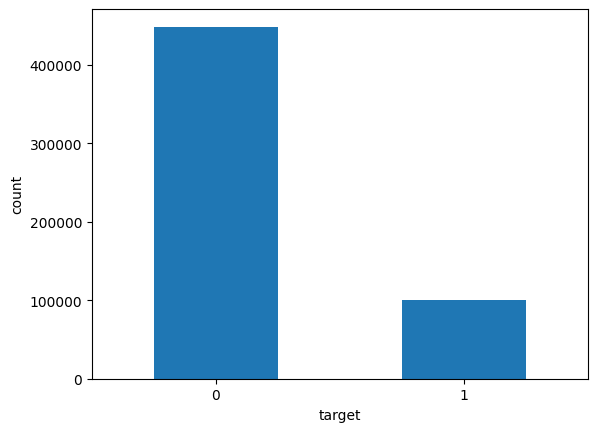

<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.Tensor size changed, may indicate binary incompatibility. Expected 64 from C header, got 80 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.ChunkedArray size changed, may indicate binary incompatibility. Expected 64 from C header, got 72 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib._Tabular size changed, may indicate binary incompatibility. Expected 24 from C header, got 32 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.Table size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.NativeFile size changed, may indicate binary incompatibility. Expected 96 from C header, got 104 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.BufferedInputStream size changed, may indicate binary incompatibility. Expected 

Fold 0:
--> fold train size: (113585, 327)
--> fold valid size: (17388, 327)
--> fold test size: (17388, 327)


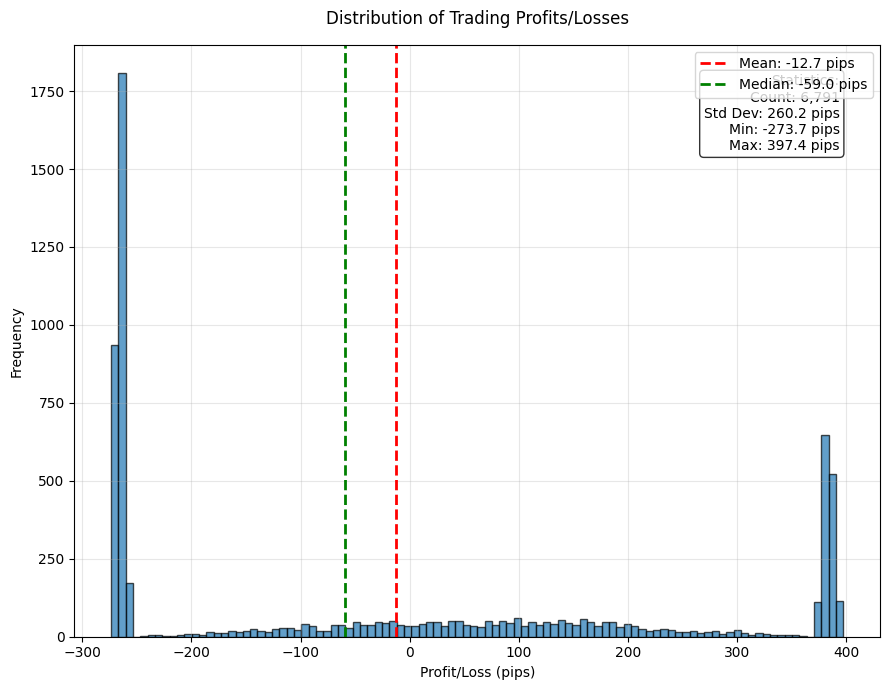

win trade:
 confidence_levels
1.0    100.0
Name: proportion, dtype: float64
**
loss trade:
 confidence_levels
1.0    100.0
Name: proportion, dtype: float64


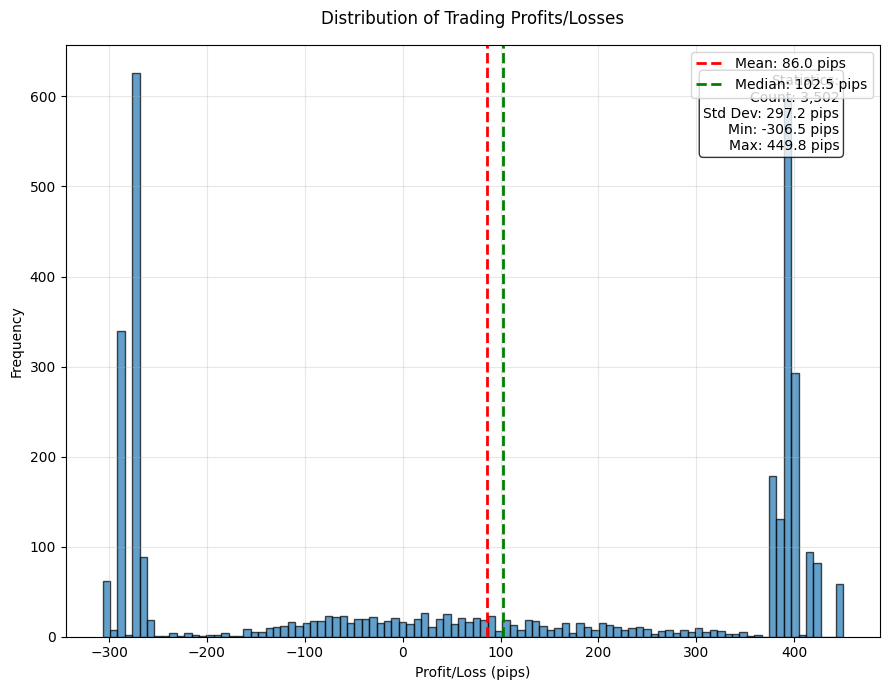

win trade:
 confidence_levels
0.0    99.048096
0.5     0.851703
0.6     0.100200
Name: proportion, dtype: float64
**
loss trade:
 confidence_levels
0.0    99.933599
0.5     0.066401
Name: proportion, dtype: float64
  dataset  K  f1_score  precision  recall     TP     FP     TN    FN  \
0   train  0      0.58       0.41    0.99  17263  24676  71426   220   
1   valid  0      0.25       0.16    0.54   1076   5715   9688   909   
2    test  0      0.31       0.33    0.29   1159   2343  11051  2835   

             Min_date  ... train_duration profit_percent  max_dd  \
0 2017-04-19 03:55:00  ...     36.4 + 2.6            NaN     NaN   
1 2019-02-19 16:20:00  ...           18.4         -24.53  -29.13   
2 2019-05-20 16:20:00  ...            6.7           0.85   -0.03   

   max_exp_daily_dd  max_overall_dd  n_unique_days n_max_daily_sig  \
0               NaN             NaN           None            None   
1             -3.96          -26.21             64             244   
2            

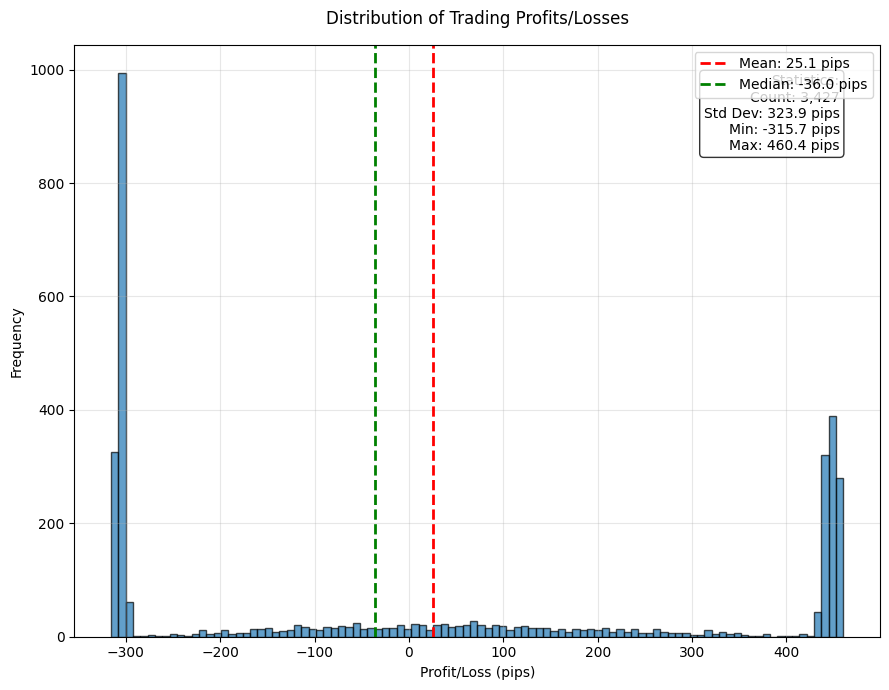

win trade:
 confidence_levels
1.0    100.0
Name: proportion, dtype: float64
**
loss trade:
 confidence_levels
1.0    100.0
Name: proportion, dtype: float64


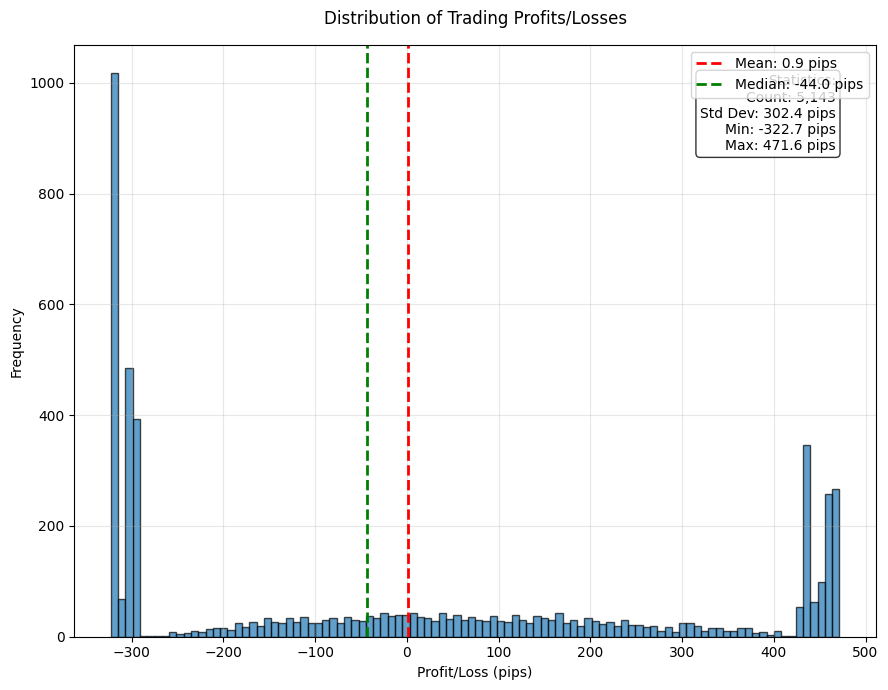

win trade:
 confidence_levels
0.0    100.0
Name: proportion, dtype: float64
**
loss trade:
 confidence_levels
0.0    100.0
Name: proportion, dtype: float64
  dataset  K  f1_score  precision  recall     TP     FP     TN    FN  \
3   train  1      0.52       0.35    0.99  22044  40184  85912   221   
4   valid  1      0.22       0.20    0.24    681   2746  11769  2192   
5    test  1      0.23       0.18    0.32    947   4196  10270  1975   

             Min_date  ... train_duration profit_percent  max_dd  \
3 2017-04-19 03:55:00  ...     34.6 + 2.8            NaN     NaN   
4 2019-08-15 16:20:00  ...           17.7          19.18  -20.57   
5 2019-11-12 16:20:00  ...            7.4           0.00    0.00   

   max_exp_daily_dd  max_overall_dd  n_unique_days n_max_daily_sig  \
3               NaN             NaN           None            None   
4              -3.9           -3.85             52             240   
5               0.0            0.00             57             245   

 

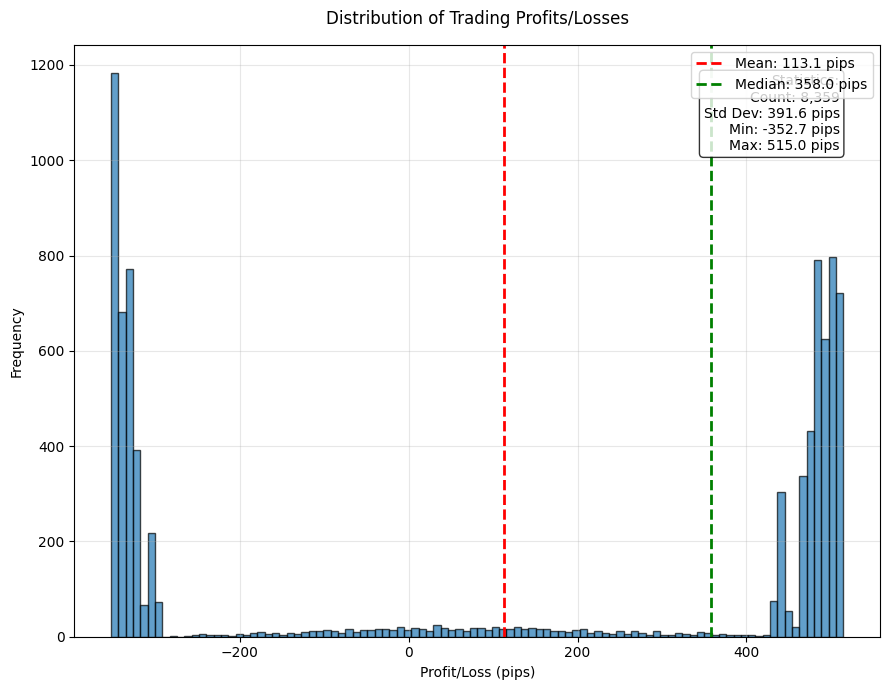

win trade:
 confidence_levels
1.0    100.0
Name: proportion, dtype: float64
**
loss trade:
 confidence_levels
1.0    100.0
Name: proportion, dtype: float64


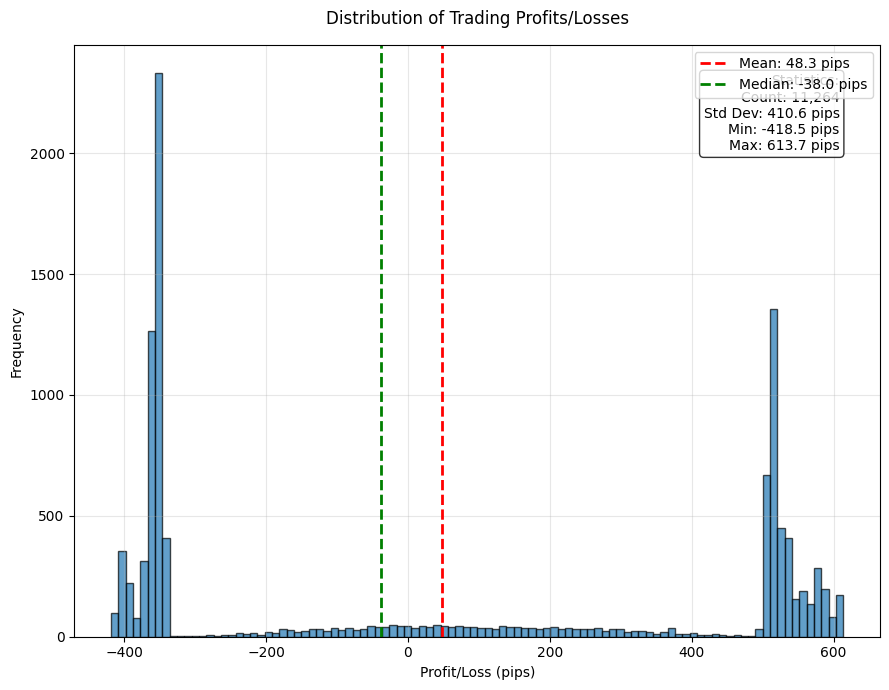

win trade:
 confidence_levels
0.0    99.232176
0.5     0.694698
0.6     0.073126
Name: proportion, dtype: float64
**
loss trade:
 confidence_levels
0.0    99.585778
0.5     0.396962
0.6     0.017259
Name: proportion, dtype: float64
  dataset  K  f1_score  precision  recall     TP     FP     TN    FN  \
6   train  2      0.47       0.31    0.99  28864  64304  89701   268   
7   valid  2      0.40       0.29    0.65   2436   5923   7716  1313   
8    test  2      0.37       0.24    0.77   2738   8526   5312   812   

             Min_date  ... train_duration profit_percent  max_dd  \
6 2017-04-19 03:55:00  ...     40.9 + 3.0            NaN     NaN   
7 2020-02-11 16:20:00  ...           20.1        1122.47  -11.63   
8 2020-05-11 16:20:00  ...           10.6           1.30   -0.46   

   max_exp_daily_dd  max_overall_dd  n_unique_days n_max_daily_sig  \
6               NaN             NaN           None            None   
7             -3.96           -3.46             64             262

In [ ]:
if MANUAL_EXP:
    exp_obj, exp_metadata, artifact_name = main(
        manual = True,
        man_params = man_params[model_type],
    )

In [77]:
imp_fe = list(exp_obj.feature_importance[exp_obj.feature_importance.cv<.5].feature_name)
exp_obj.feature_importance[exp_obj.feature_importance.cv<.5].feature_name

13                           fe_time_hour
881    fe_market_close_EURUSD_Sydney_time
877    fe_market_close_EURUSD_London_time
277    fe_market_close_XAUUSD_London_time
19                 fe_ATR_XAUUSD_W30_M240
                      ...                
14                         fe_time_minute
605             fe_WIN_argmax_US30_W10_M5
909           fe_WIN_argmax_EURUSD_W10_M5
603             fe_WIN_argmin_US30_W10_M5
601              fe_WIN_argmax_US30_W5_M5
Name: feature_name, Length: 806, dtype: object

In [78]:
def plot_feature_importances_scatter(importance_df, top_n=10, figsize=(8, 6)):
    # Calculate mean importance and sort features
    mean_importance = importance_df['mean_importance']
    sorted_idx = mean_importance.argsort()[::-1]
    top_features = importance_df.iloc[sorted_idx[:top_n]]
    imp_cols = [f for f in importance_df if 'importance_fold' in f]
    # Prepare data for scatter plot
    feature_names = top_features['feature_name']
    importance_values = top_features[imp_cols].values.T  # Transpose for plotting

    # Calculate median importance
    median_importance = top_features['median_importance']

    # Create scatter plot
    fig, ax = plt.subplots(figsize=figsize)
    
    for i, feature in enumerate(feature_names):
        ax.scatter([i] * importance_values.shape[0], importance_values[:, i], 
                   alpha=0.6, label=feature)

    # Plot median line
    ax.plot(range(top_n), median_importance, color='red', linestyle='--', 
            linewidth=2, label='Median')
    
    # Add value labels on the median line
    for i, v in enumerate(median_importance):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

    ax.set_xlabel('Features', fontsize=12)
    ax.set_ylabel('Feature Importance', fontsize=12)
    ax.set_title(f'Top {top_n} Feature Importances Across Folds with Median', fontsize=14)
    ax.set_xticks(range(top_n))
    ax.set_xticklabels(feature_names, rotation=45, ha='right')
#     ax.legend(title='Features', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

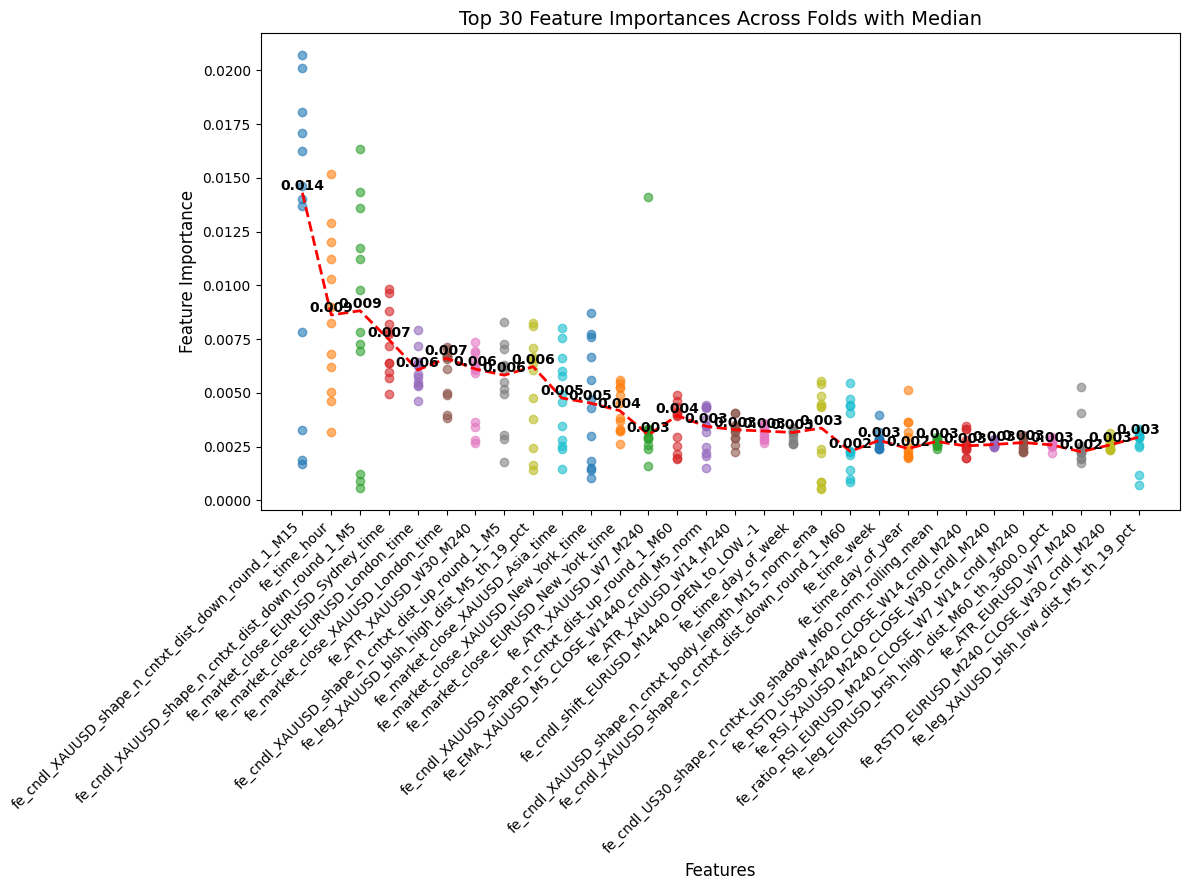

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
plot_feature_importances_scatter(exp_obj.feature_importance, top_n=30, figsize=(12, 9))

### Save manual object on W&B as Artifact

In [50]:
if MANUAL_EXP:
    wandb.init(entity = 'alpha-hunters', project = 'algotrading-project')
    obj_artifact = wandb.Artifact(artifact_name, 'manual_experiment', metadata = exp_metadata)
    obj_artifact.add_file(local_path=exp_obj.store_name+'.zip', name=exp_obj.store_name+'.zip')
    wandb.log_artifact(obj_artifact)

In [51]:
if MANUAL_EXP:
    wandb.finish()

## Save imp_features (when we have RANDOM features)

In [53]:
if MANUAL_EXP:
    upload_imp_features = True
    symbol = man_params[model_type]['target_symbol']
    trade_mode = man_params[model_type]['trade_mode']
    look_ahead = man_params[model_type]['trg_look_ahead']
    take_profit = man_params[model_type]['trg_take_profit']
    stop_loss = man_params[model_type]['trg_stop_loss']

In [54]:
if MANUAL_EXP and upload_imp_features :
    print('save_imp_features ')
    import pickle as pkl
    the_name = f"df_feature_imp_{trade_mode}_{symbol}_M{look_ahead}_TP{take_profit}_SL{stop_loss}.pkl"
    file = open(the_name, 'wb')
    pkl.dump(exp_obj.feature_importance,file)
    file.close()
    
    imp_artifact_name = artifact_name + '_imp_features'
    wandb.init(entity = 'alpha-hunters', project = 'algotrading-project', job_type="feature_selection")
    imp_artifact = wandb.Artifact(imp_artifact_name, 'feature_selection', metadata = exp_metadata)
    imp_artifact.add_file(local_path = the_name,name = the_name)
    print(f"--> dataset size MB: {imp_artifact.size / 1000000}")
    wandb.log_artifact(imp_artifact)
    wandb.finish()

save_imp_features 


--> dataset size MB: 0.014092


# 2. Sweep Experiment using W&B

In [55]:
#? https://www.kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning/notebook
sweep_configs = {}
sweep_configs['RF'] = {
    "method": "grid",
#     "metric": {"name": "class 1 f0.03_score_train", "goal": "maximize"},
#     'description':description,
    "parameters": {
        'model_name' : {"values": ['RF']},
        
        'target_symbol' : {"values": ['EURUSD']},
        'trade_mode' : {"values": ['long']},
        "trg_look_ahead": {"values": [120]},
        "trg_take_profit": {"values": [12]},
        "trg_stop_loss": {"values": [5]},
        
        "strg_look_ahead": {"values": [120]},
        "strg_take_profit": {"values": [12]},
        "strg_stop_loss": {"values": [5]},
        
        'save_model_mode' : {"values": ['last_train_size']}, # None, 'sample_train_size', 'last_train_size', 'all_data',
        'imp_features' : {"values": [None]},  #  can be set to imp_features or None
        'n_rand_features': {"values": [None]},
        "early_stopping_rounds" :{"values": [None]},
        "n_splits" : {"values": [17]},
        "max_train_size": {"values": [500*288]},
        'test_size' : {"values": [30*288]},
        'train_test_gap' : {"values": [0]},

        
        'n_estimators' : {"values": [200]},
        'max_depth': {"values": [5,12]},
        'max_features' : {"values": [30, 50,80]},
        'max_samples' : {"values": [0.2,0.3,0.4]},
        'class_weight':{'values':[0.13,0.15, 0.18, 0.23]},
        'n_jobs': {"values": [-1]},
        'random_state' : {"values": [42]},
                       
#         "objective": {"values": ["binary:logistic"]},
        
#         "max_depth": {"values": [2, 5, 8, 15, 20, 30]},
#         "learning_rate": {"distribution": "uniform", "min": 0.005, "max": 0.01},
#         "n_estimators": {"distribution": "int_uniform", "min": 50, "max": 300},
#         "min_child_weight": {"distribution": "uniform", "min": 0, "max": 1}, # Used to control over-fitting.
#         "subsample": {"distribution": "uniform", "min": 0.3, "max": 0.5 } ,#Lower values make the algorithm more conservative and prevents overfitting but too small values might lead to under-fitting.

        
#         "early_stopping_rounds" :{"distribution": "int_uniform", "min": 5, "max": 150},
#         "early_stopping_rounds" :{"values": [40,200]},
#         "gamma": {"distribution": "uniform", "min": 0, "max": 15}, #? float
#         "max_delta_step": {"distribution": "uniform", "min": 0, "max": 15}, #?float
#         "colsample_bytree": {"distribution": "uniform", "min": 0.5, "max": 0.75}, 
#         "reg_lambda": {"distribution": "uniform", "min": 0, "max": 10},
#         "reg_alpha": {"distribution": "uniform", "min": 0, "max": 10},   
#         "train_data_precent": {"distribution": "uniform", "min": 0, "max": 0.98},
#         "train_data_precent": {"distribution": "uniform", "min": 0.5, "max": 0.95},
    },
}

In [56]:
sweep_configs['XGB'] = {
    "method": "grid",
    
    "parameters": {
        'model_name' : {"values": ['XGB']},
        
        'target_symbol' : {"values": ['EURUSD']}, # ["EURUSD","USDCAD","USDJPY","EURJPY","GBPUSD","XAUUSD"]
        'trade_mode' : {"values": ['long']}, # "long", "short"
        "trg_look_ahead": {"values": [300]},
        "trg_take_profit": {"values": [35]},
        "trg_stop_loss": {"values": [5]},
        
        "strg_look_ahead": {"values": [480]},
        "strg_take_profit": {"values": [40]},
        "strg_stop_loss": {"values": [15]},
                
        'n_rand_features': {"values": [None]}, # None or Number
        'save_model_mode' : {"values": [None]}, # None, 'sample_train_size', 'last_train_size', 'all_data',

        "early_stopping_rounds" :{"values": [None]}, #None or Number
        'n_splits' : {"values":[3]},
        'max_train_size' : {"values":[400*288,300*288]},
        'test_size' : {"values":[30*288]},
        'train_test_gap' : {"values": [0]},
        
        "objective": {"values": ["binary:logistic"]},
        "max_depth": {"values": [4,5]},
        "learning_rate": {"values": [0.1,0.01,0.05]},
        'tree_method': {"values": [None]}, #'hist', None
        'device' : {"values": ["cpu"]}, # 'cuda', None
#         "learning_rate": {"distribution": "log_uniform", "min": 1e-5, "max": 5e-1},
        "n_estimators": {"values": [100]},
#         "early_stopping_rounds" :{"distribution": "int_uniform", "min": 5, "max": 150},
#         "early_stopping_rounds" :{"values": [40,200]},
#         "gamma": {"distribution": "uniform", "min": 0, "max": 15}, #? float
        "min_child_weight": {"values": [1]}, # Used to control over-fitting.
#         "max_delta_step": {"distribution": "uniform", "min": 0, "max": 15}, #?float
        "subsample": {"values": [0.3,0.5,0.8]},#Lower values make the algorithm more conservative and prevents overfitting but too small values might lead to under-fitting.
        "colsample_bytree": {"values": [0.5,0.8]},
        "reg_lambda": {"values": [0,0.02,0.1]},
#         "reg_alpha": {"distribution": "uniform", "min": 0, "max": 10},
        "scale_pos_weight" : {"values": [1]},#[1,0.95,1.1]
        'random_state': {"values":[42]},
        },
}

In [57]:
%%time

sweep_id = wandb.sweep(
    sweep_configs[model_type],
    entity = 'alpha-hunters',
    project = 'algotrading-project'
)

#!!!!!!!!!!!! SWEEP ID !!!!!!!!!!!!!!!!!
wandb.agent(sweep_id = sweep_id, function = main, entity = 'alpha-hunters',project = 'algotrading-project')
wandb.finish()

Create sweep with ID: ti7uvmrq
Sweep URL: https://wandb.ai/alpha-hunters/algotrading-project/sweeps/ti7uvmrq


wandb: Agent Starting Run: jd05j808 with config:
wandb: 	colsample_bytree: 0.5
wandb: 	device: cpu
wandb: 	early_stopping_rounds: None
wandb: 	learning_rate: 0.1
wandb: 	max_depth: 4
wandb: 	max_train_size: 115200
wandb: 	min_child_weight: 1
wandb: 	model_name: XGB
wandb: 	n_estimators: 100
wandb: 	n_rand_features: None
wandb: 	n_splits: 3
wandb: 	objective: binary:logistic
wandb: 	random_state: 42
wandb: 	reg_lambda: 0
wandb: 	save_model_mode: None
wandb: 	scale_pos_weight: 1
wandb: 	strg_look_ahead: 480
wandb: 	strg_stop_loss: 15
wandb: 	strg_take_profit: 40
wandb: 	subsample: 0.3
wandb: 	target_symbol: EURUSD
wandb: 	test_size: 8640
wandb: 	trade_mode: long
wandb: 	train_test_gap: 0
wandb: 	tree_method: None
wandb: 	trg_look_ahead: 300
wandb: 	trg_stop_loss: 5
wandb: 	trg_take_profit: 35


Final Parameters of the Model: {'colsample_bytree': 0.5, 'device': 'cpu', 'early_stopping_rounds': None, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 100, 'objective': 'binary:logistic', 'random_state': 42, 'reg_lambda': 0, 'scale_pos_weight': 1, 'subsample': 0.3, 'tree_method': None}
Len all columns in dataframe is 180
Len read columns is 180
Calculating target --->
---> Target trg_clf_long_EURUSD_M300_TP35_SL5 has been generated in 2.84 seconds
df shape:  (135577, 181)
--> df final shape: (135577, 180)
--> df min_time: 2023-01-10 03:55:00 | df max_time: 2024-10-29 21:55:00
--> number of unique days: 135577
Fold 0:
--> fold train size: (83737, 185)
--> fold valid size: (8640, 185)
--> fold test size: (8640, 185)
  dataset  K  f1_score  precision  recall   TP  FP     TN    FN  \
0   train  0      0.31       0.93    0.18  576  46  80542  2573   
1   valid  0      0.00       0.00    0.00    0   7   8470   163   
2    test  0      0.00       0.00    0.00   

f1_score_ex0_test,▁
f1_score_ex0_train,▁
f1_score_ex0_valid,▁
f1_score_ex0_valid&test,▁
max_dd_mean_test,▁
max_dd_mean_valid,▁
max_dd_mean_valid&test,▁
max_dd_median_test,▁
max_dd_median_valid,▁
max_dd_median_valid&test,▁
max_dd_min_test,▁


wandb: Agent Starting Run: ht1twxtr with config:
wandb: 	colsample_bytree: 0.5
wandb: 	device: cpu
wandb: 	early_stopping_rounds: None
wandb: 	learning_rate: 0.1
wandb: 	max_depth: 4
wandb: 	max_train_size: 115200
wandb: 	min_child_weight: 1
wandb: 	model_name: XGB
wandb: 	n_estimators: 100
wandb: 	n_rand_features: None
wandb: 	n_splits: 3
wandb: 	objective: binary:logistic
wandb: 	random_state: 42
wandb: 	reg_lambda: 0
wandb: 	save_model_mode: None
wandb: 	scale_pos_weight: 1
wandb: 	strg_look_ahead: 480
wandb: 	strg_stop_loss: 15
wandb: 	strg_take_profit: 40
wandb: 	subsample: 0.5
wandb: 	target_symbol: EURUSD
wandb: 	test_size: 8640
wandb: 	trade_mode: long
wandb: 	train_test_gap: 0
wandb: 	tree_method: None
wandb: 	trg_look_ahead: 300
wandb: 	trg_stop_loss: 5
wandb: 	trg_take_profit: 35


...

wandb: Agent Starting Run: 583iddg2 with config:
wandb: 	colsample_bytree: 0.5
wandb: 	device: cpu
wandb: 	early_stopping_rounds: None
wandb: 	learning_rate: 0.1
wandb: 	max_depth: 4
wandb: 	max_train_size: 115200
wandb: 	min_child_weight: 1
wandb: 	model_name: XGB
wandb: 	n_estimators: 100
wandb: 	n_rand_features: None
wandb: 	n_splits: 3
wandb: 	objective: binary:logistic
wandb: 	random_state: 42
wandb: 	reg_lambda: 0
wandb: 	save_model_mode: None
wandb: 	scale_pos_weight: 1
wandb: 	strg_look_ahead: 480
wandb: 	strg_stop_loss: 15
wandb: 	strg_take_profit: 40
wandb: 	subsample: 0.8
wandb: 	target_symbol: EURUSD
wandb: 	test_size: 8640
wandb: 	trade_mode: long
wandb: 	train_test_gap: 0
wandb: 	tree_method: None
wandb: 	trg_look_ahead: 300
wandb: 	trg_stop_loss: 5
wandb: 	trg_take_profit: 35


Final Parameters of the Model: {'colsample_bytree': 0.5, 'device': 'cpu', 'early_stopping_rounds': None, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 100, 'objective': 'binary:logistic', 'random_state': 42, 'reg_lambda': 0, 'scale_pos_weight': 1, 'subsample': 0.8, 'tree_method': None}
Len all columns in dataframe is 180
Len read columns is 180
Calculating target --->
---> Target trg_clf_long_EURUSD_M300_TP35_SL5 has been generated in 2.94 seconds
df shape:  (135577, 181)
--> df final shape: (135577, 180)
--> df min_time: 2023-01-10 03:55:00 | df max_time: 2024-10-29 21:55:00
--> number of unique days: 135577
Fold 0:
--> fold train size: (83737, 185)
--> fold valid size: (8640, 185)
--> fold test size: (8640, 185)


wandb: Ctrl + C detected. Stopping sweep.


CPU times: user 2min 47s, sys: 6.38 s, total: 2min 53s
Wall time: 2min 7s
  dataset  K  f1_score  precision  recall   TP  FP     TN    FN  \
0   train  0      0.31       0.93    0.18  577  46  80542  2572   
1   valid  0      0.00       0.00    0.00    0   2   8475   163   
2    test  0      0.00       0.00    0.00    0   0   8415   225   

             Min_date            Max_date train_duration  profit_percent  \
0 2023-01-10 03:55:00 2024-02-20 21:55:00            6.4             NaN   
1 2024-02-20 22:00:00 2024-04-02 21:55:00            6.4            -3.4   
2 2024-04-02 22:00:00 2024-05-14 21:55:00            6.4             0.0   

   max_dd n_unique_days n_max_daily_sig  
0     NaN          None            None  
1   -1.73             1               2  
2    0.00             0             NaN  Socket operation on non-socket


Traceback (most recent call last):


In [58]:
# Import necessary libraries
import wandb

# The sweep ID should be the same as the one you started with
# Resume the sweep
wandb.agent(sweep_id=sweep_id, function=main, entity='alpha-hunters', project='algotrading-project')

# Finish the sweep
wandb.finish()

wandb: Agent Starting Run: 4nbufjaf with config:
wandb: 	colsample_bytree: 0.5
wandb: 	device: cpu
wandb: 	early_stopping_rounds: None
wandb: 	learning_rate: 0.1
wandb: 	max_depth: 4
wandb: 	max_train_size: 115200
wandb: 	min_child_weight: 1
wandb: 	model_name: XGB
wandb: 	n_estimators: 100
wandb: 	n_rand_features: None
wandb: 	n_splits: 3
wandb: 	objective: binary:logistic
wandb: 	random_state: 42
wandb: 	reg_lambda: 0.02
wandb: 	save_model_mode: None
wandb: 	scale_pos_weight: 1
wandb: 	strg_look_ahead: 480
wandb: 	strg_stop_loss: 15
wandb: 	strg_take_profit: 40
wandb: 	subsample: 0.3
wandb: 	target_symbol: EURUSD
wandb: 	test_size: 8640
wandb: 	trade_mode: long
wandb: 	train_test_gap: 0
wandb: 	tree_method: None
wandb: 	trg_look_ahead: 300
wandb: 	trg_stop_loss: 5
wandb: 	trg_take_profit: 35


Final Parameters of the Model: {'colsample_bytree': 0.5, 'device': 'cpu', 'early_stopping_rounds': None, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 100, 'objective': 'binary:logistic', 'random_state': 42, 'reg_lambda': 0.02, 'scale_pos_weight': 1, 'subsample': 0.3, 'tree_method': None}
Len all columns in dataframe is 180
Len read columns is 180
Calculating target --->
---> Target trg_clf_long_EURUSD_M300_TP35_SL5 has been generated in 2.97 seconds
df shape:  (135577, 181)
--> df final shape: (135577, 180)
--> df min_time: 2023-01-10 03:55:00 | df max_time: 2024-10-29 21:55:00
--> number of unique days: 135577
Fold 0:
--> fold train size: (83737, 185)
--> fold valid size: (8640, 185)
--> fold test size: (8640, 185)
  dataset  K  f1_score  precision  recall   TP  FP     TN    FN  \
0   train  0       0.3       0.92    0.18  555  49  80539  2594   
1   valid  0       0.0       0.00    0.00    0   2   8475   163   
2    test  0       0.0       0.00    0.00

wandb: Ctrl + C detected. Stopping sweep.


  dataset  K  f1_score  precision  recall   TP  FP      TN    FN  \
6   train  2      0.28       0.94    0.16  615  39  111410  3136   
7   valid  2      0.00       0.00    0.00    0   0    8474   166   
8    test  2      0.00       0.00    0.00    0   0    8443   197   

             Min_date            Max_date train_duration  profit_percent  \
6 2023-01-24 22:00:00 2024-08-06 21:55:00            7.4             NaN   
7 2024-08-06 22:00:00 2024-09-17 21:55:00            7.4             0.0   
8 2024-09-17 22:00:00 2024-10-29 21:55:00            7.4             0.0   

   max_dd n_unique_days n_max_daily_sig  
6     NaN          None            None  
7     0.0             0             NaN  
8     0.0             0             NaN  
CV loop ends
{'profit_percent_val': 2.25, 'max_dd_val': 0.0, 'profit_percent_test': -1.7, 'max_dd_test': 0.0}


Traceback (most recent call last):
Exception in thread Thread-22 (_run_job):
Traceback (most recent call last):
  File "/kaggle/working/ML-Algotrading-Project/main_func.py", line 237, in main
    exp_obj.store_obj()
  File "/kaggle/working/ML-Algotrading-Project/experiment_tracker.py", line 59, in store_obj
    print(f"object stored as pickle: {self.store_name}")
  File "/opt/conda/lib/python3.10/site-packages/ipykernel/iostream.py", line 694, in write
    self._schedule_flush()
  File "/opt/conda/lib/python3.10/site-packages/ipykernel/iostream.py", line 590, in _schedule_flush
    self.pub_thread.schedule(_schedule_in_thread)
  File "/opt/conda/lib/python3.10/site-packages/ipykernel/iostream.py", line 267, in schedule
    self._event_pipe.send(b"")
  File "/opt/conda/lib/python3.10/site-packages/zmq/sugar/socket.py", line 701, in send
    return super().send(data, flags=flags, copy=copy, track=track)
  File "_zmq.py", line 1073, in zmq.backend.cython._zmq.Socket.send
  File "_zmq.py",

object stored as pickle: XGB_long_EURUSD_M300_TP35_SL5_prof-1.70_max_dd0.00_median_sig0.00_date2024-10-30_17:49.pklSocket operation on non-socket


In [ ]:
#STOP SWEEP
if not MANUAL_EXP:
    print('Finishing The SWEEP ...')
    print(f'{1/0}')

# Filter models from W&B

In [ ]:
runs_filter = {'path' : "alpha-hunters/algotrading-project",# /artifacts/experiment/trg_clf_long_EURUSD_M240_TP25_SL10
               "order": "+summary_metrics.profit_percent_test",
    'filters': {"$and": [  
#                         {"state":'finished'},
                        {"createdAt":{ '$gte': '2024-06-01' }},
                        {"sweep":'jmw8zpy9'},
        
                        ########### GENERAL CONFIG #############
                        {"config.target_symbol":'EURUSD'}, 
                        {"config.trade_mode": 'long'},
#                         {"config.look_ahead": 480},
#                         {"config.strg_take_profit": 40},
#                         {"config.strg_stop_loss": 15},
                        {"config.model_name":'XGB'},
#                         ########### MODEL CONFIG #############
#                         {"config.max_depth": 3 },
#                         {"config.n_estimators": { "$gte": 100 } },
#                         {"config.learning_rate": { "$lt": 1 }},
#                         {"config.random_state": 42 },
                        
                        ########### MODEL METRICS #############
                        {"summary_metrics.profit_percent_test" : { "$gte": 10}},
                        {"summary_metrics.profit_percent_val" : { "$gte": 10}},
                        
                        {"summary_metrics.profit_percent_median_test" : { "$gte": 5}},
                        {"summary_metrics.profit_percent_median_valid" : { "$gte": 5}},
        
                        {"summary_metrics.max_dd_min_test" : { "$gte":-40}},
                        {"summary_metrics.max_dd_min_valid" : { "$gte":-40}},

                        {"summary_metrics.max_dd_test" : { "$gte":-40}},
                        {"summary_metrics.max_dd_val" : { "$gte":-40}},

        

                                ]
            }
}
runs=api.runs(**runs_filter)
print(len(runs))

In [ ]:
# wandb.finish()

In [ ]:
import shutil
import os
if os.path.isdir("/kaggle/working/artifacts"):
    shutil.rmtree("/kaggle/working/artifacts")
meta_datas=fetch_artifacts(runs_filter)

In [ ]:
objects = read_tracker_objects("/kaggle/working/artifacts")

In [ ]:
# objects['XGB_long_USDJPY_M300_TP35_SL5_prof531.41_max_dd-56.54_median_sig9.00_date2024-07-08_21:24']['obj'].evals

## Selected Models' Config

In [ ]:
import pandas as pd
for i,k in enumerate(objects):
    if i == 0:
        df_config = pd.DataFrame(objects[k]['obj'].config, index = [0])
#         display(df_config)
    else:
        df_config = pd.concat([df_config,pd.DataFrame(objects[k]['obj'].config, index = [0])])
# df_config[['colsample_bytree',
#        'learning_rate', 'trg_look_ahead', 'max_depth', 'max_train_size',
#        'min_child_weight', 'model_name', 'n_estimators', 'save_model_mode', 'scale_pos_weight',
#        'subsample', 'trg_take_profit', 'target_symbol', 'tree_method']]
df_config

## Feature Importance

In [ ]:
for i,k in enumerate(objects):
    if i == 0:
        df_imp = objects[k]['obj'].feature_importance
        df_imp.rename(columns = {'importances': f'importances_{i}'}, inplace =True)
    else:
        
        df_imp = df_imp.merge(objects[k]['obj'].feature_importance.rename(columns = {'importances': f'importances_{i}'}),
                             on = 'feature_name')
imp_cols = [f for f in df_imp.columns if 'importances_' in f]
df_imp['imp_mean'] =df_imp[imp_cols].mean(axis = 1)
df_imp.sort_values('imp_mean', ascending = False)[:30]

## Models' Correlation

In [ ]:
import pandas as pd
def cal_corr_tar1_predictions(objects):
    '''Calculate corrilation between models Just for target==1'''
    corr_ls=[]
    for i,n in enumerate(objects):

        val_predictions = objects[n]['obj'].val_predictions
        val_predictions=val_predictions[val_predictions.target==1][['pred_as_val','target']].replace(0, -1)
        corr_ls.append((n,val_predictions))
    print("Total_model_count:", len(corr_ls))
        
    from sklearn.metrics import matthews_corrcoef
    corr_dict={}
    for i in range(0,len(corr_ls)):
        for j in range(i+1,len(corr_ls)):
            corr_dict[(corr_ls[i][0],corr_ls[j][0])]=matthews_corrcoef(corr_ls[i][1]['pred_as_val'], corr_ls[j][1]['pred_as_val'])
        
        
    corr_df=pd.DataFrame([k + (v,) for k, v in corr_dict.items()], columns=['model1', 'model2', 'M_corr'])
    print('combination checked:', corr_df.shape[0])
    corr_df.hist('M_corr')
    return corr_df

corr_df=cal_corr_tar1_predictions(objects)

In [ ]:
# corr_df[corr_df.M_corr<0.7]
corr_df